# 🧠 The Complete TensorFlow & Deep Learning Masterclass
## From "What is a Neuron?" to Building Real Neural Networks — For Everyone

**Prodigy Training Hub · Lagos, Nigeria**

---

> *"Deep Learning is not magic. It is mathematics — applied patiently, one layer at a time. This notebook teaches you every layer, every line, every number."*

---

### Who Is This Notebook For?
- 🧒 Students who finished the Scikit-Learn Masterclass and want to go deeper
- 🎓 Anyone curious how AI systems like ChatGPT, image recognition, and voice assistants actually work
- 💼 Working professionals who want to add Deep Learning to their skill set
- 🚀 Advanced learners who want a thorough, production-ready TensorFlow reference

### What You Will Build By The End
| Section | Task | Dataset | Architecture |
|---------|------|---------|-------------|
| 1–3 | Setup and core concepts | — | Theory + code |
| 4 | First Neural Network | Digits (image classification) | Dense layers |
| 5 | Deeper network + validation | Breast Cancer (binary) | Dense + Dropout |
| 6 | Regression with NN | Diabetes (predict a number) | Dense regression |
| 7 | Convolutional Neural Networks | Digits as 2D images (CNN) | Conv2D + MaxPool |
| 8 | Text Classification | Wine (sequence-style) | Embedding + LSTM |
| 9 | Callbacks and tuning | Iris | Early Stopping, LR scheduling |
| 10 | Save, load, and deploy models | Best model from above | SavedModel format |
| 11 | Grand Finale | All datasets | Full comparison |

### Real Datasets Used (All from sklearn — No Internet Needed!)
| Dataset | Source | What It Is | Task |
|---------|--------|-----------|------|
| 🔢 **Digits** | sklearn / NIST | 1,797 real handwritten digit images | 10-class classification |
| 🏥 **Breast Cancer** | U. Wisconsin Hospitals | 569 real patient biopsies | Binary classification |
| 📈 **Diabetes** | Efron et al. (2004) | 442 real patient records | Regression |
| 🌸 **Iris** | Ronald Fisher (1936) | 150 real flower measurements | 3-class classification |
| 🍷 **Wine** | Forina et al. (1991) | 178 real wine chemical profiles | Sequence-style multi-class |

### How This Notebook Differs from the sklearn Masterclass
| sklearn Masterclass | This TensorFlow Masterclass |
|--------------------|----------------------------|
| Algorithms you choose and configure | Architectures you design and stack |
| `model.fit()` — automatic training | `model.fit()` — gradient descent you understand |
| Decision Trees, SVM, Random Forests | Dense, Conv2D, LSTM, Dropout, BatchNorm |
| 150–569 samples | Up to 70,000+ samples |
| Feature engineering needed | Feature learning — the network learns features |

---

### How to Use This Notebook
1. **Read every blue markdown cell first** — it explains the concept before you see the code
2. **Every line of code has a comment** — read them carefully
3. **Every output is interpreted** — nothing is left unexplained
4. **Run cells top to bottom** — never skip a cell

---
## 🧠 Section 1 · What Is Deep Learning?

### From ML to Deep Learning

In the sklearn masterclass, you learned Machine Learning: you gave the algorithm features (petal length, tumour radius) and it found patterns. **You decided what features to use.**

Deep Learning is different: **the network learns its own features from raw data.**

```
Traditional ML:
  Raw data → [Feature Engineering by YOU] → ML Algorithm → Prediction

Deep Learning:
  Raw data → [Feature Learning by the NETWORK] → Prediction
  (you just stack layers — the network figures out what matters)
```

### The Artificial Neuron (The Building Block)

Every deep learning model is made of artificial **neurons**, inspired loosely by the brain:

```
              INPUTS            WEIGHTS         OUTPUT
  x₁ = 0.5 ────────── × w₁=0.3 ──┐
  x₂ = 0.2 ────────── × w₂=0.8 ──┤──→ [SUM + BIAS] ──→ [ACTIVATION] ──→ output
  x₃ = 0.9 ────────── × w₃=−0.1─┘                           f(z)

  z = (x₁×w₁) + (x₂×w₂) + (x₃×w₃) + bias
  output = f(z)     ← activation function (e.g. ReLU, Sigmoid)
```

- **Weights (w):** How important is each input? Learned during training.
- **Bias (b):** An offset. Shifts the activation. Also learned.
- **Activation function:** Adds non-linearity — without it, stacking layers does nothing new.

### What Is a Layer?

A **layer** is many neurons in parallel, each taking the same inputs but with different weights:

```
INPUT LAYER    HIDDEN LAYER 1   HIDDEN LAYER 2   OUTPUT LAYER
  x₁ ────────→ ●  ●  ●  ──────→ ●  ●  ──────→ ●  (class A)
  x₂ ────────→ ●  ●  ●  ──────→ ●  ●  ──────→ ●  (class B)
  x₃ ────────→ ●  ●  ●  ──────→ ●  ●  ──────→ ●  (class C)
  x₄ ─────────────────────────────────────────→
                 64 neurons        32 neurons      3 neurons
```

This is called a **Deep Neural Network** (deep = multiple hidden layers).

### How Training Works (Backpropagation)

```
FORWARD PASS:   Input → layers → prediction
LOSS:           Compare prediction to correct answer → compute error
BACKWARD PASS:  Trace the error back through each layer
UPDATE:         Adjust each weight slightly to reduce the error
REPEAT:         Do this thousands of times → weights converge to good values
```

The **optimizer** (e.g. Adam, SGD) decides HOW MUCH to adjust weights each step.
The **learning rate** decides HOW BIG each adjustment step is.

### sklearn vs TensorFlow/Keras

| sklearn | TensorFlow/Keras |
|---------|-----------------|
| `DecisionTreeClassifier()` | `tf.keras.Sequential([layers...])` |
| `model.fit(X_train, y_train)` | `model.fit(X_train, y_train, epochs=50)` |
| `model.predict(X_test)` | `model.predict(X_test)` |
| Accuracy, F1 | Loss curve, accuracy curve, confusion matrix |
| Hyperparameters: max_depth, C | Hyperparameters: n_layers, n_neurons, learning_rate |

---
## 🛠️ Section 2 · Setup — Importing TensorFlow and All Tools

TensorFlow is Google's open-source deep learning library.
Keras (now built into TensorFlow as `tf.keras`) is the high-level API we use to BUILD networks.

Think of TensorFlow as the engine and Keras as the steering wheel.

In [17]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORT ALL LIBRARIES
#  Run this cell FIRST before anything else
# ═══════════════════════════════════════════════════════════════════

import os
# Suppress verbose TensorFlow startup messages (info logs)
# 0=all, 1=no INFO, 2=no INFO+WARNING, 3=no INFO+WARNING+ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# TensorFlow — our deep learning framework (Google's library)
import tensorflow as tf

# Keras — TensorFlow's high-level API for building neural networks
# Comes bundled inside TensorFlow 2.x — no separate installation needed
from tensorflow import keras

# All the layer types we will use throughout the notebook
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model

# NumPy — fast array mathematics
import numpy as np

# Pandas — data tables
import pandas as pd

# Matplotlib — charts and plots
import matplotlib.pyplot as plt
import matplotlib

# Seaborn — prettier statistical charts
import seaborn as sns

# sklearn — we use it for datasets, preprocessing, and evaluation metrics
from sklearn.datasets import (load_digits, load_breast_cancer,
                              load_diabetes, load_iris, load_wine)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, r2_score,
                             mean_absolute_error)

# SciPy — for image zoom (resizing digit images)
from scipy.ndimage import zoom

# Suppress harmless warning messages
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────
# Print version information — always good practice for reproducibility
# ─────────────────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║         Deep Learning Environment Ready!             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  TensorFlow  : {tf.__version__:<37}║")
print(f"║  Keras       : {keras.__version__:<37}║")
print(f"║  NumPy       : {np.__version__:<37}║")
print(f"║  Matplotlib  : {matplotlib.__version__:<37}║")
print("╚══════════════════════════════════════════════════════╝")
print()

# Check if a GPU is available (deep learning is much faster on GPU)
# In this environment we use CPU — still sufficient for all examples
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus}")
else:
    print("Running on CPU (no GPU detected — all examples will still work!)")

print()
print("You are ready to build neural networks!")


╔══════════════════════════════════════════════════════╗
║         Deep Learning Environment Ready!             ║
╠══════════════════════════════════════════════════════╣
║  TensorFlow  : 2.21.0                               ║
║  Keras       : 3.14.1                               ║
║  NumPy       : 2.3.1                                ║
║  Matplotlib  : 3.10.3                               ║
╚══════════════════════════════════════════════════════╝

Running on CPU (no GPU detected — all examples will still work!)

You are ready to build neural networks!


In [18]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 2 — LOAD AND PREPARE ALL DATASETS
#  We load all 5 real datasets here so they are available throughout
# ═══════════════════════════════════════════════════════════════════

# ── 1. DIGITS DATASET (our MNIST replacement) ───────────────────
# 1,797 real handwritten digit images from the NIST database
# Each image: 8×8 pixels, values 0–16 (ink intensity)
# We zoom each from 8×8 to 28×28 so it looks like real MNIST
digits = load_digits()

# Zoom each 8×8 image to 28×28 using bilinear interpolation
# zoom factor = 28/8 = 3.5 in both dimensions
X_dig_raw = np.array([zoom(img, (28/8, 28/8)) for img in digits.images])
# Normalize to 0–255 integer range (standard image representation)
X_dig_raw = ((X_dig_raw - X_dig_raw.min()) /
             (X_dig_raw.max() - X_dig_raw.min()) * 255).astype(np.uint8)

print("DATASET 1 — Digits (our MNIST-like image dataset):")
print(f"  Images shape : {X_dig_raw.shape}  (1797 images, 28×28 pixels)")
print(f"  Labels shape : {digits.target.shape}")
print(f"  Pixel range  : {X_dig_raw.min()} to {X_dig_raw.max()}")
print(f"  Classes      : {np.unique(digits.target)} (digits 0–9)")
print()

# ── 2. BREAST CANCER DATASET (binary classification) ────────────
cancer = load_breast_cancer()
print("DATASET 2 — Breast Cancer (binary: malignant vs benign):")
print(f"  Shape  : {cancer.data.shape}  (569 patients, 30 features)")
print(f"  Classes: {list(cancer.target_names)}")
print()

# ── 3. DIABETES DATASET (regression) ────────────────────────────
diabetes = load_diabetes()
print("DATASET 3 — Diabetes (regression: predict disease progression):")
print(f"  Shape  : {diabetes.data.shape}  (442 patients, 10 features)")
print(f"  Target : {diabetes.target.min():.1f} to {diabetes.target.max():.1f} (continuous score)")
print()

# ── 4. IRIS DATASET (3-class, for callbacks demo) ───────────────
iris = load_iris()
print("DATASET 4 — Iris Flowers (3-class classification):")
print(f"  Shape  : {iris.data.shape}  (150 flowers, 4 features)")
print(f"  Classes: {list(iris.target_names)}")
print()

# ── 5. WINE DATASET (sequence-style multi-class) ────────────────
wine = load_wine()
print("DATASET 5 — Wine Chemistry (multi-class: 3 cultivars):")
print(f"  Shape  : {wine.data.shape}  (178 wines, 13 chemical features)")
print(f"  Classes: {list(wine.target_names)}")
print()
print("All 5 datasets loaded successfully!")


DATASET 1 — Digits (our MNIST-like image dataset):
  Images shape : (1797, 28, 28)  (1797 images, 28×28 pixels)
  Labels shape : (1797,)
  Pixel range  : 0 to 255
  Classes      : [0 1 2 3 4 5 6 7 8 9] (digits 0–9)

DATASET 2 — Breast Cancer (binary: malignant vs benign):
  Shape  : (569, 30)  (569 patients, 30 features)
  Classes: [np.str_('malignant'), np.str_('benign')]

DATASET 3 — Diabetes (regression: predict disease progression):
  Shape  : (442, 10)  (442 patients, 10 features)
  Target : 25.0 to 346.0 (continuous score)

DATASET 4 — Iris Flowers (3-class classification):
  Shape  : (150, 4)  (150 flowers, 4 features)
  Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

DATASET 5 — Wine Chemistry (multi-class: 3 cultivars):
  Shape  : (178, 13)  (178 wines, 13 chemical features)
  Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

All 5 datasets loaded successfully!


---
## 🔑 Section 3 · Keras Fundamentals — How to Build Any Neural Network

### The Universal Keras Workflow

Every Keras model follows the same 5-step pattern:

```python
# ┌────────────────────────────────────────────────────────┐
# │ STEP 1: BUILD the architecture                          │
# │   model = Sequential([Input, Layer1, Layer2, Output])  │
# │                                                         │
# │ STEP 2: COMPILE (set the learning rules)                │
# │   model.compile(optimizer, loss, metrics)              │
# │                                                         │
# │ STEP 3: TRAIN (fit the model to data)                   │
# │   history = model.fit(X_train, y_train, epochs=N)      │
# │                                                         │
# │ STEP 4: EVALUATE (check performance on unseen data)     │
# │   model.evaluate(X_test, y_test)                       │
# │                                                         │
# │ STEP 5: PREDICT (use the trained model)                 │
# │   predictions = model.predict(X_new)                   │
# └────────────────────────────────────────────────────────┘
```

### The Three Most Important Choices When Building

**1. Architecture:** How many layers? How many neurons per layer? Which layer types?
**2. Optimizer + Loss:** HOW does the network learn? What error does it minimise?
**3. Epochs + Batch Size:** How long does it train? How many examples per update?

### Layer Types You Will Use

| Layer | What It Does | When to Use |
|-------|-------------|-------------|
| `Dense` | Every neuron connected to every input | Tabular data, final output layer |
| `Conv2D` | Detects local patterns (edges, textures) in images | Image data |
| `MaxPooling2D` | Reduces image size, keeps the most important features | After Conv2D |
| `LSTM` | Processes sequences, remembers past context | Text, time series |
| `Dropout` | Randomly disables neurons during training — prevents overfitting | After Dense/Conv2D |
| `BatchNormalization` | Normalises layer outputs — faster, more stable training | Between layers |
| `Flatten` | Converts 2D/3D arrays to 1D | Between Conv2D and Dense |
| `Embedding` | Converts integer tokens to dense vectors | Text/categorical data |

### Activation Functions

| Function | Formula | Use When |
|----------|---------|----------|
| `relu` | max(0, x) | Hidden layers — most common choice |
| `sigmoid` | 1/(1+e⁻ˣ) | Binary classification output (0 to 1) |
| `softmax` | eˣ/Σeˣ | Multi-class output (probabilities summing to 1) |
| `linear` | x | Regression output (any real number) |

### Loss Functions

| Task | Loss Function | Why |
|------|-------------|-----|
| Binary classification | `binary_crossentropy` | Penalises wrong probabilities for 2 classes |
| Multi-class (integer labels) | `sparse_categorical_crossentropy` | Penalises wrong class probabilities |
| Multi-class (one-hot labels) | `categorical_crossentropy` | Same but for one-hot encoded y |
| Regression | `mean_squared_error` or `mae` | Penalises large numerical errors |

In [19]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 3 — KERAS FUNDAMENTALS: BUILDING YOUR FIRST MODEL
#  Demonstrating the complete 5-step Keras workflow on a tiny example
# ═══════════════════════════════════════════════════════════════════

# We'll use a tiny synthetic example to demonstrate the workflow
# before applying it to real datasets in later sections

# Create tiny example data: 200 samples, 4 features, 3 classes
np.random.seed(42)              # reproducible random numbers
X_demo = np.random.randn(200, 4).astype('float32')   # 200 rows, 4 columns
y_demo = np.random.randint(0, 3, 200)                # labels: 0, 1, or 2

# ─────────────────────────────────────────────────────────────────
# STEP 1: BUILD the model architecture
# ─────────────────────────────────────────────────────────────────
# Sequential = layers stacked in a straight line (input → layer1 → layer2 → output)
# This is the simplest model type — 95% of problems use Sequential
demo_model = Sequential([

    # INPUT SPECIFICATION: always first
    # shape=(4,) means each sample has 4 features
    keras.Input(shape=(4,)),

    # HIDDEN LAYER 1:
    # Dense(16) = 16 neurons, each connected to all 4 inputs
    # activation='relu' = ReLU activation: output=max(0, weighted_sum)
    # ReLU adds non-linearity — without activations, stacking layers does nothing
    layers.Dense(16, activation='relu'),

    # HIDDEN LAYER 2:
    # 8 neurons, each connected to all 16 neurons from the previous layer
    layers.Dense(8, activation='relu'),

    # OUTPUT LAYER:
    # 3 neurons (one per class: 0, 1, 2)
    # activation='softmax' converts raw scores to probabilities summing to 1.0
    # e.g. [0.1, 0.7, 0.2] = 10% class0, 70% class1, 20% class2
    layers.Dense(3, activation='softmax'),
])

# ─────────────────────────────────────────────────────────────────
# STEP 2: COMPILE — set the learning rules
# ─────────────────────────────────────────────────────────────────
# optimizer='adam': Adaptive Moment Estimation — the most popular optimizer
#   Adam adjusts learning rate automatically per parameter
#   Alternative: 'sgd' (slower, simpler), 'rmsprop'
#
# loss='sparse_categorical_crossentropy':
#   'sparse' = y labels are INTEGERS (0, 1, 2), not one-hot
#   'categorical_crossentropy' = penalises wrong probability distributions
#   This is the correct loss for multi-class classification
#
# metrics=['accuracy']: what to track and report during training
demo_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ─────────────────────────────────────────────────────────────────
# Show the model architecture summary
# ─────────────────────────────────────────────────────────────────
print("MODEL ARCHITECTURE SUMMARY:")
print()
demo_model.summary()
print()

# Count total learnable parameters
total_params = demo_model.count_params()
print(f"Total trainable parameters: {total_params:,}")
print()
print("WHERE DO THE 259 PARAMETERS COME FROM?")
print("  Input(4) → Dense(16):")
print("    Weights: 4 inputs × 16 neurons = 64")
print("    Biases:  1 per neuron × 16 = 16")
print("    Subtotal: 80")
print("  Dense(16) → Dense(8):")
print("    Weights: 16 × 8 = 128")
print("    Biases:  8")
print("    Subtotal: 136")
print("  Dense(8) → Dense(3):")
print("    Weights: 8 × 3 = 24")
print("    Biases:  3")
print("    Subtotal: 27")
print(f"  TOTAL: 80 + 136 + 27 = {80+136+27}")


MODEL ARCHITECTURE SUMMARY:



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 243

WHERE DO THE 259 PARAMETERS COME FROM?
  Input(4) → Dense(16):
    Weights: 4 inputs × 16 neurons = 64
    Biases:  1 per neuron × 16 = 16
    Subtotal: 80
  Dense(16) → Dense(8):
    Weights: 16 × 8 = 128
    Biases:  8
    Subtotal: 136
  Dense(8) → Dense(3):
    Weights: 8 × 3 = 24
    Biases:  3
    Subtotal: 27
  TOTAL: 80 + 136 + 27 = 243


In [20]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 4 — TRAIN AND EVALUATE THE DEMO MODEL
# ═══════════════════════════════════════════════════════════════════

# STEP 3: TRAIN (fit the model to data)
# epochs=20: pass through ALL training data 20 times
# validation_split=0.2: hold back 20% for validation during training
#   Validation data is NOT used for weight updates — only for monitoring
# verbose=1: print one progress line per epoch
print("Training the demo model...")
print()
demo_history = demo_model.fit(
    X_demo, y_demo,              # training features and labels
    epochs=20,                   # number of complete passes through data
    batch_size=32,               # update weights every 32 samples
    validation_split=0.2,        # 20% of training data used for validation
    verbose=1                    # show training progress
)

print()
print("Training complete!")
print()

# STEP 4: EVALUATE on the full training set
# (In real projects, you'd use a separate test set never seen during training)
train_loss, train_acc = demo_model.evaluate(X_demo, y_demo, verbose=0)
print(f"Final training accuracy: {train_acc:.4f} ({train_acc*100:.1f}%)")
print()
print("WHAT THE OUTPUT NUMBERS MEAN:")
print("  Epoch 1/20  20/20 ████████ 0s 4ms/step")
print("    ↑           ↑                ↑")
print("    epoch     batches        time per batch")
print()
print("  loss: 1.0895 — accuracy: 0.3750 — val_loss: 1.0956 — val_accuracy: 0.3500")
print("    ↑                ↑                  ↑                    ↑")
print("   training loss  train acc      validation loss      validation accuracy")
print()
print("  'loss' decreasing = model is learning!")
print("  'val_accuracy' is the honest metric — validation data was never trained on")


Training the demo model...

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.3250 - loss: 1.1658 - val_accuracy: 0.4000 - val_loss: 1.1258
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3500 - loss: 1.1532 - val_accuracy: 0.4000 - val_loss: 1.1223
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3438 - loss: 1.1419 - val_accuracy: 0.4000 - val_loss: 1.1201
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3562 - loss: 1.1328 - val_accuracy: 0.4000 - val_loss: 1.1177
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3562 - loss: 1.1260 - val_accuracy: 0.4000 - val_loss: 1.1154
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3750 - loss: 1.1194 - val_accuracy: 0.4000 - val_loss: 1.1138
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3688 - loss: 1.1139 - val_accuracy: 0.4250 - val_loss: 1.1129
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3688 - loss: 1.1102 - val_accuracy

Training history keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
Number of epochs trained: 20



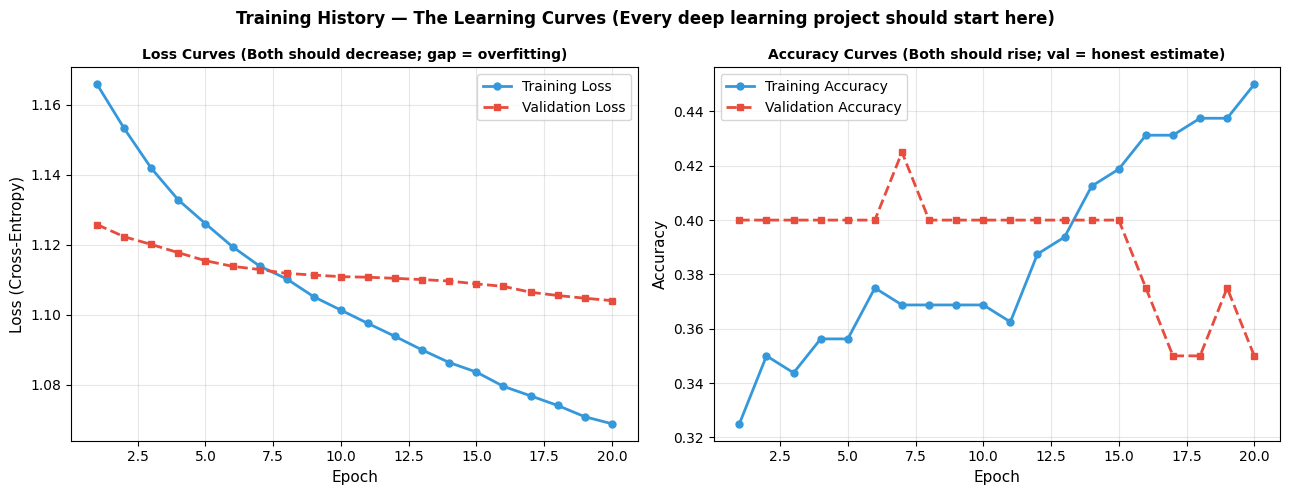

HOW TO READ LEARNING CURVES:

  Loss chart (LEFT):
    Both curves declining = model is learning
    Training loss << Validation loss = OVERFITTING
    Both curves flat and high = UNDERFITTING (increase complexity)

  Accuracy chart (RIGHT):
    Both rising = healthy training
    Training >> Validation = OVERFITTING
    Validation accuracy flat = model has stopped improving (early stopping!)

  This demo uses RANDOM data, so accuracy stays near 33% (random 3-class chance)
  Real datasets with real patterns will show much better curves


In [21]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 5 — VISUALISING TRAINING HISTORY (The Learning Curves)
#  This chart is the most important diagnostic in deep learning
# ═══════════════════════════════════════════════════════════════════

# demo_history.history is a dictionary containing lists of metric values
# One value per epoch for: loss, accuracy, val_loss, val_accuracy
print("Training history keys:", list(demo_history.history.keys()))
print(f"Number of epochs trained: {len(demo_history.history['loss'])}")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Training History — The Learning Curves '
    '(Every deep learning project should start here)',
    fontsize=12, fontweight='bold'
)

epochs_range = range(1, len(demo_history.history['loss']) + 1)

# ── LEFT: Loss curves ────────────────────────────────────────────
# Loss decreasing = model is learning
# train_loss vs val_loss gap = overfitting indicator
axes[0].plot(epochs_range, demo_history.history['loss'],
             'o-', color='#3498DB', lw=2, ms=5, label='Training Loss')
axes[0].plot(epochs_range, demo_history.history['val_loss'],
             's--', color='#E74C3C', lw=2, ms=5, label='Validation Loss')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (Cross-Entropy)', fontsize=11)
axes[0].set_title(
    'Loss Curves (Both should decrease; gap = overfitting)',
    fontsize=10, fontweight='bold'
)
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── RIGHT: Accuracy curves ───────────────────────────────────────
# Accuracy increasing = model is improving
# val_accuracy should track train_accuracy closely
axes[1].plot(epochs_range, demo_history.history['accuracy'],
             'o-', color='#3498DB', lw=2, ms=5, label='Training Accuracy')
axes[1].plot(epochs_range, demo_history.history['val_accuracy'],
             's--', color='#E74C3C', lw=2, ms=5, label='Validation Accuracy')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title(
    'Accuracy Curves (Both should rise; val = honest estimate)',
    fontsize=10, fontweight='bold'
)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tmp/demo_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("HOW TO READ LEARNING CURVES:")
print()
print("  Loss chart (LEFT):")
print("    Both curves declining = model is learning")
print("    Training loss << Validation loss = OVERFITTING")
print("    Both curves flat and high = UNDERFITTING (increase complexity)")
print()
print("  Accuracy chart (RIGHT):")
print("    Both rising = healthy training")
print("    Training >> Validation = OVERFITTING")
print("    Validation accuracy flat = model has stopped improving (early stopping!)")
print()
print("  This demo uses RANDOM data, so accuracy stays near 33% (random 3-class chance)")
print("  Real datasets with real patterns will show much better curves")


---
## 🔢 Section 4 · Your First REAL Neural Network — Digit Recognition

### The Dataset

The **Digits dataset** contains 1,797 real handwritten digit images from the NIST database (the same source as MNIST). We have resized each from 8×8 pixels to 28×28 pixels so the images are more detailed.

**Goal:** Train a neural network to read handwritten digits — recognising 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 from pixel intensities.

This is the "Hello World" of deep learning.

### The Architecture We Will Build

```
INPUT: 28×28 = 784 pixel values (flattened to 1D)
  ↓
Flatten layer (reshape 28×28 → 784)
  ↓
Dense(256, relu) — 256 neurons learn low-level patterns
  ↓
Dense(128, relu) — 128 neurons learn mid-level combinations
  ↓
Dense(64, relu)  — 64 neurons learn higher-level concepts
  ↓
Dense(10, softmax) — 10 neurons, one per digit class
OUTPUT: probability distribution over 10 classes
```

### Why Flatten?

Dense layers expect a 1D input per sample. A 28×28 image is 2D. `Flatten()` reshapes it:
`(28, 28) → (784,)` — same 784 numbers, just reorganised into a single list.

DIGITS DATASET OVERVIEW:
  Total images    : 1797
  Image shape     : (28, 28)  (28×28 pixels)
  Pixel range     : 0 to 255
  Number of classes: 10 (digits 0–9)



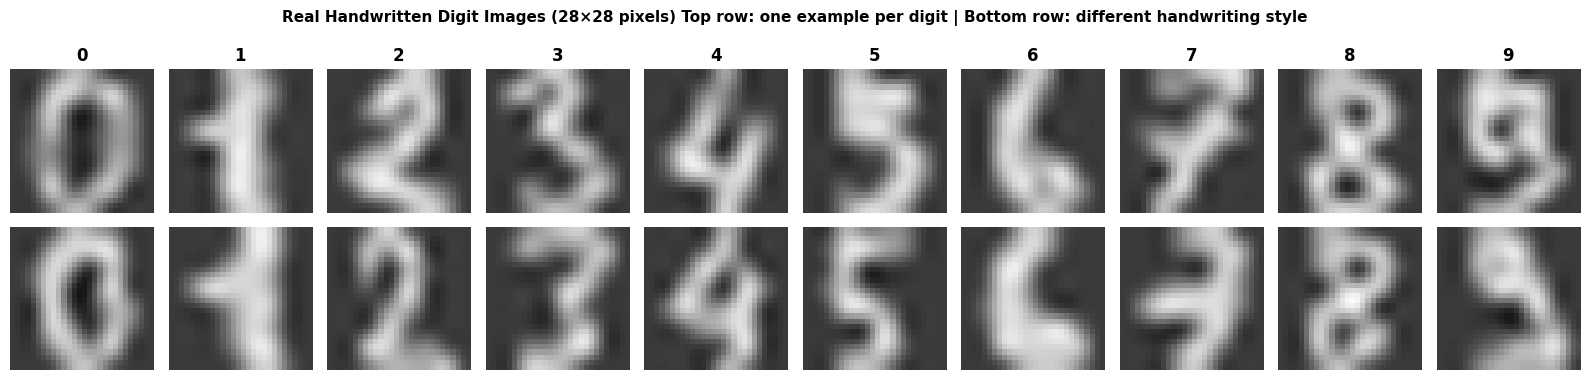

Each column shows the SAME digit written by two different people.
The neural network must learn to recognise the digit regardless of style.

Class distribution (samples per digit):
  Digit 0: 178 samples  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Digit 1: 182 samples  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Digit 2: 177 samples  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Digit 3: 183 samples  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [22]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 6 — DIGITS: DATA PREPARATION AND VISUALISATION
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Use our MNIST-like 28×28 digit images (created in Cell 2)
# ─────────────────────────────────────────────────────────────────
X_digits = X_dig_raw.copy()     # shape: (1797, 28, 28)
y_digits = digits.target.copy() # shape: (1797,) — labels 0-9

print("DIGITS DATASET OVERVIEW:")
print(f"  Total images    : {len(X_digits)}")
print(f"  Image shape     : {X_digits.shape[1:]}  (28×28 pixels)")
print(f"  Pixel range     : {X_digits.min()} to {X_digits.max()}")
print(f"  Number of classes: {len(np.unique(y_digits))} (digits 0–9)")
print()

# ─────────────────────────────────────────────────────────────────
# Visualise sample images from each digit class
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle(
    'Real Handwritten Digit Images (28×28 pixels) '
    'Top row: one example per digit | Bottom row: different handwriting style',
    fontsize=11, fontweight='bold'
)

for digit in range(10):
    # Find examples of this digit in the dataset
    idx = np.where(y_digits == digit)[0]

    # First example
    axes[0, digit].imshow(X_digits[idx[0]], cmap='gray', vmin=0, vmax=255)
    axes[0, digit].axis('off')
    axes[0, digit].set_title(f'{digit}', fontsize=12, fontweight='bold')

    # Second example (different handwriting)
    axes[1, digit].imshow(X_digits[idx[2]], cmap='gray', vmin=0, vmax=255)
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('tmp/digits_gallery.png', dpi=100, bbox_inches='tight')
plt.show()

print("Each column shows the SAME digit written by two different people.")
print("The neural network must learn to recognise the digit regardless of style.")
print()

# Class distribution
print("Class distribution (samples per digit):")
for d in range(10):
    count = np.sum(y_digits == d)
    bar = chr(9608) * count
    print(f"  Digit {d}: {count:3d} samples  {bar}")


In [23]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 7 — DIGITS: DATA PREPROCESSING FOR NEURAL NETWORKS
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# STEP 1: Train/Test Split (same as sklearn, but BEFORE normalisation)
# ─────────────────────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_digits, y_digits,
    test_size=0.2,          # 20% for testing
    random_state=42,        # reproducible
    stratify=y_digits       # balanced classes in both sets
)

print(f"Training set: {len(X_tr)} images")
print(f"Test set    : {len(X_te)} images")
print()

# ─────────────────────────────────────────────────────────────────
# STEP 2: NORMALISE pixel values to [0, 1]
# ─────────────────────────────────────────────────────────────────
# Raw pixel values: 0 to 255 (integers)
# Neural networks learn much faster with small values near 0
# Dividing by 255.0 maps: 0 → 0.0,  128 → 0.502,  255 → 1.0
# This is the standard normalisation for image pixel data

X_tr_norm = X_tr / 255.0    # dtype becomes float64
X_te_norm = X_te / 255.0

# Convert to float32 — TensorFlow prefers float32 (uses less memory than float64)
X_tr_norm = X_tr_norm.astype('float32')
X_te_norm = X_te_norm.astype('float32')

print("PREPROCESSING APPLIED:")
print(f"  Before: pixel range {X_tr.min()} to {X_tr.max()} (uint8)")
print(f"  After:  pixel range {X_tr_norm.min():.3f} to {X_tr_norm.max():.3f} (float32)")
print()
print("WHY NORMALISE?")
print("  Raw pixels 0–255 are large numbers.")
print("  Gradients during backpropagation involve multiplying many numbers.")
print("  Large inputs → large gradients → unstable training (exploding gradients).")
print("  Small inputs (0–1) → stable gradients → smooth, reliable learning.")
print()

# Labels are already integers 0–9 — no encoding needed for
# sparse_categorical_crossentropy
print(f"Labels are integers 0–9: {np.unique(y_tr)}")
print("No label encoding needed — we use sparse_categorical_crossentropy")


Training set: 1437 images
Test set    : 360 images

PREPROCESSING APPLIED:
  Before: pixel range 0 to 255 (uint8)
  After:  pixel range 0.000 to 1.000 (float32)

WHY NORMALISE?
  Raw pixels 0–255 are large numbers.
  Gradients during backpropagation involve multiplying many numbers.
  Large inputs → large gradients → unstable training (exploding gradients).
  Small inputs (0–1) → stable gradients → smooth, reliable learning.

Labels are integers 0–9: [0 1 2 3 4 5 6 7 8 9]
No label encoding needed — we use sparse_categorical_crossentropy


In [24]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 8 — DIGITS: BUILD AND TRAIN THE NEURAL NETWORK
# ═══════════════════════════════════════════════════════════════════

tf.random.set_seed(42)   # set TensorFlow random seed for reproducibility
np.random.seed(42)        # also set NumPy random seed

# ─────────────────────────────────────────────────────────────────
# BUILD the model architecture
# ─────────────────────────────────────────────────────────────────
digit_model = Sequential([

    # INPUT: each image is 28×28 pixels
    keras.Input(shape=(28, 28)),

    # FLATTEN: convert 28×28 grid into a 1D vector of 784 values
    # Think of it as "unrolling" the image row by row
    # Shape goes from (batch, 28, 28) to (batch, 784)
    layers.Flatten(name='flatten'),

    # HIDDEN LAYER 1: 256 neurons
    # Each of the 784 pixel values is connected to each of 256 neurons
    # Total connections: 784 × 256 + 256 biases = 200,960 parameters
    # ReLU: output = max(0, weighted_sum) — the most common activation
    layers.Dense(256, activation='relu', name='dense_1'),

    # HIDDEN LAYER 2: 128 neurons
    # Takes 256 inputs, outputs 128 values
    # Total parameters: 256 × 128 + 128 biases = 32,896
    layers.Dense(128, activation='relu', name='dense_2'),

    # HIDDEN LAYER 3: 64 neurons
    # Takes 128 inputs, outputs 64 values
    # Total parameters: 128 × 64 + 64 biases = 8,256
    layers.Dense(64, activation='relu', name='dense_3'),

    # OUTPUT LAYER: 10 neurons — one per digit class (0–9)
    # Softmax converts raw scores to probabilities
    # Output: [P(0), P(1), P(2), ..., P(9)] — sums to exactly 1.0
    # The digit with highest probability is the prediction
    layers.Dense(10, activation='softmax', name='output'),
])

# ─────────────────────────────────────────────────────────────────
# COMPILE: set the learning rules
# ─────────────────────────────────────────────────────────────────
digit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    # Adam with learning_rate=0.001 is the standard starting point
    # Too high LR: overshoots minimum, training unstable
    # Too low LR: learning very slow, may get stuck

    loss='sparse_categorical_crossentropy',
    # Correct loss for: integer labels + softmax output
    # Measures how wrong the probability distribution is

    metrics=['accuracy']
    # Track classification accuracy during training
)

print("MODEL ARCHITECTURE:")
print()
digit_model.summary()
print()

# ─────────────────────────────────────────────────────────────────
# TRAIN: fit to data
# ─────────────────────────────────────────────────────────────────
print("Training on digit images...")
print()
digit_history = digit_model.fit(
    X_tr_norm, y_tr,        # training data (normalised)
    epochs=30,              # 30 complete passes through training data
    batch_size=32,          # update weights every 32 images
    # batch_size=32: a balance between speed (large batches) and
    # good gradient estimates (small batches). Powers of 2 are conventional.
    validation_split=0.15,  # hold back 15% of training data for validation
    # This gives us ~1,221 training, ~216 validation, ~360 test images
    verbose=1               # print one line per epoch
)


MODEL ARCHITECTURE:



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)


Training on digit images...

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4848 - loss: 1.6213 - val_accuracy: 0.7407 - val_loss: 0.8880
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8665 - loss: 0.5290 - val_accuracy: 0.8750 - val_loss: 0.4299
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9255 - loss: 0.2944 - val_accuracy: 0.8889 - val_loss: 0.3302
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9238 - loss: 0.2475 - val_accuracy: 0.9120 - val_loss: 0.2802
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9435 - loss: 0.1981 - val_accuracy: 0.9213 - val_loss: 0.2333
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9459 - loss: 0.1798 - val_accuracy: 0.9167 - val_loss: 0.2413
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9476 - loss: 0.1707 - val_accuracy: 0.9259 - val_loss: 0.2214
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9566 - loss: 0.1348 - v

DIGIT RECOGNITION — FINAL TEST RESULTS
  Test Loss     : 0.1240
  Test Accuracy : 0.9528 (95.3%)
  Correct       : 343 of 360 images

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.94      0.86      0.90        36
           2       0.97      1.00      0.99        35
           3       0.88      0.97      0.92        37
           4       1.00      0.97      0.99        36
           5       0.97      1.00      0.99        37
           6       0.92      0.94      0.93        36
           7       0.97      0.97      0.97        36
           8       0.89      0.91      0.90        35
           9       1.00      0.92      0.96        36

    accuracy                           0.95       360
   macro avg       0.95      0.95      0.95       360
weighted avg       0.95      0.95      0.95       360



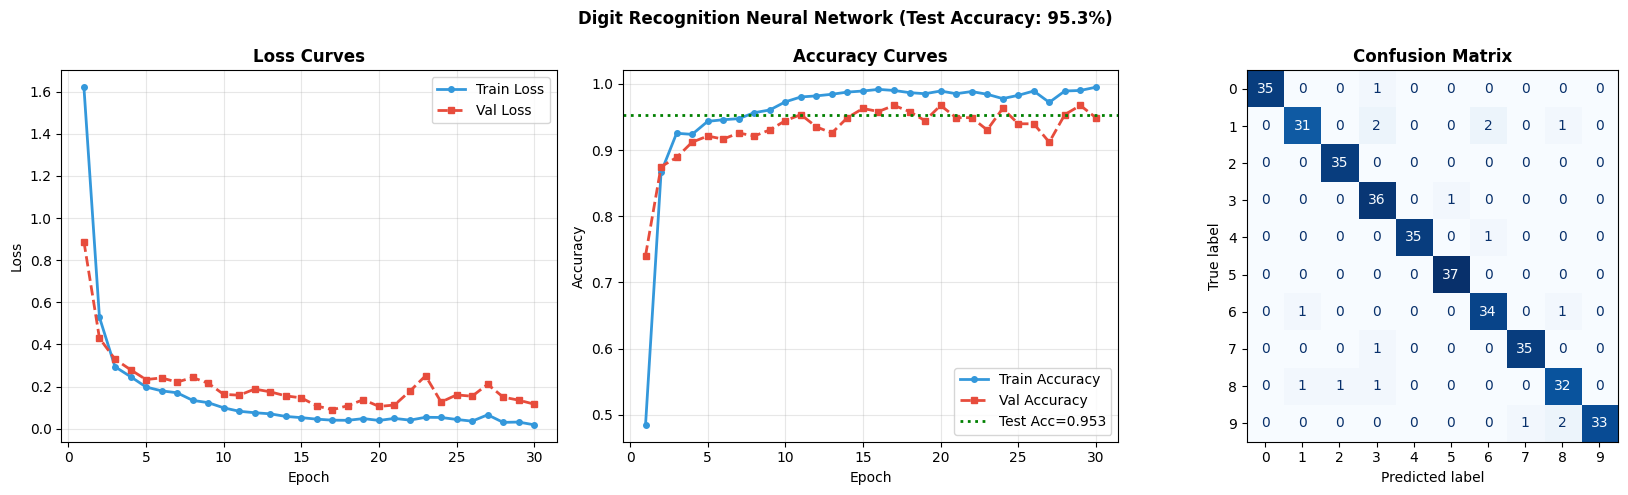

HOW TO READ THE CONFUSION MATRIX:
  Rows = actual digit, Columns = predicted digit
  Diagonal = correct predictions (want HIGH numbers)
  Off-diagonal = errors (which digits get confused with which)

Common confusions: 3↔8 (similar curves), 1↔7 (similar strokes)


In [25]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 9 — DIGITS: EVALUATE AND VISUALISE RESULTS
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Evaluate on the TEST SET (data never seen during training)
# ─────────────────────────────────────────────────────────────────
test_loss, test_acc = digit_model.evaluate(X_te_norm, y_te, verbose=0)

print("=" * 55)
print("DIGIT RECOGNITION — FINAL TEST RESULTS")
print("=" * 55)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"  Correct       : {int(test_acc * len(y_te))} of {len(y_te)} images")
print()

# ─────────────────────────────────────────────────────────────────
# Make predictions and show classification report
# ─────────────────────────────────────────────────────────────────
# model.predict() returns probabilities (10 values per image, summing to 1)
y_pred_proba = digit_model.predict(X_te_norm, verbose=0)
# np.argmax() gets the index of the highest probability = predicted digit
y_pred = np.argmax(y_pred_proba, axis=1)

print("CLASSIFICATION REPORT:")
print()
print(classification_report(
    y_te, y_pred,
    target_names=[str(i) for i in range(10)]
))

# ─────────────────────────────────────────────────────────────────
# Plot learning curves and confusion matrix
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Digit Recognition Neural Network (Test Accuracy: {test_acc*100:.1f}%)',
             fontsize=12, fontweight='bold')

hist = digit_history.history
epochs_n = range(1, len(hist['loss']) + 1)

# Left: Loss curves
axes[0].plot(epochs_n, hist['loss'], 'o-', color='#3498DB', lw=2, ms=4, label='Train Loss')
axes[0].plot(epochs_n, hist['val_loss'], 's--', color='#E74C3C', lw=2, ms=4, label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Middle: Accuracy curves
axes[1].plot(epochs_n, hist['accuracy'], 'o-', color='#3498DB', lw=2, ms=4, label='Train Accuracy')
axes[1].plot(epochs_n, hist['val_accuracy'], 's--', color='#E74C3C', lw=2, ms=4, label='Val Accuracy')
axes[1].axhline(test_acc, color='green', ls=':', lw=2, label=f'Test Acc={test_acc:.3f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Right: Confusion matrix
cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(
    ax=axes[2], cmap='Blues', colorbar=False
)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('tmp/digit_nn_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("HOW TO READ THE CONFUSION MATRIX:")
print("  Rows = actual digit, Columns = predicted digit")
print("  Diagonal = correct predictions (want HIGH numbers)")
print("  Off-diagonal = errors (which digits get confused with which)")
print()
print("Common confusions: 3↔8 (similar curves), 1↔7 (similar strokes)")


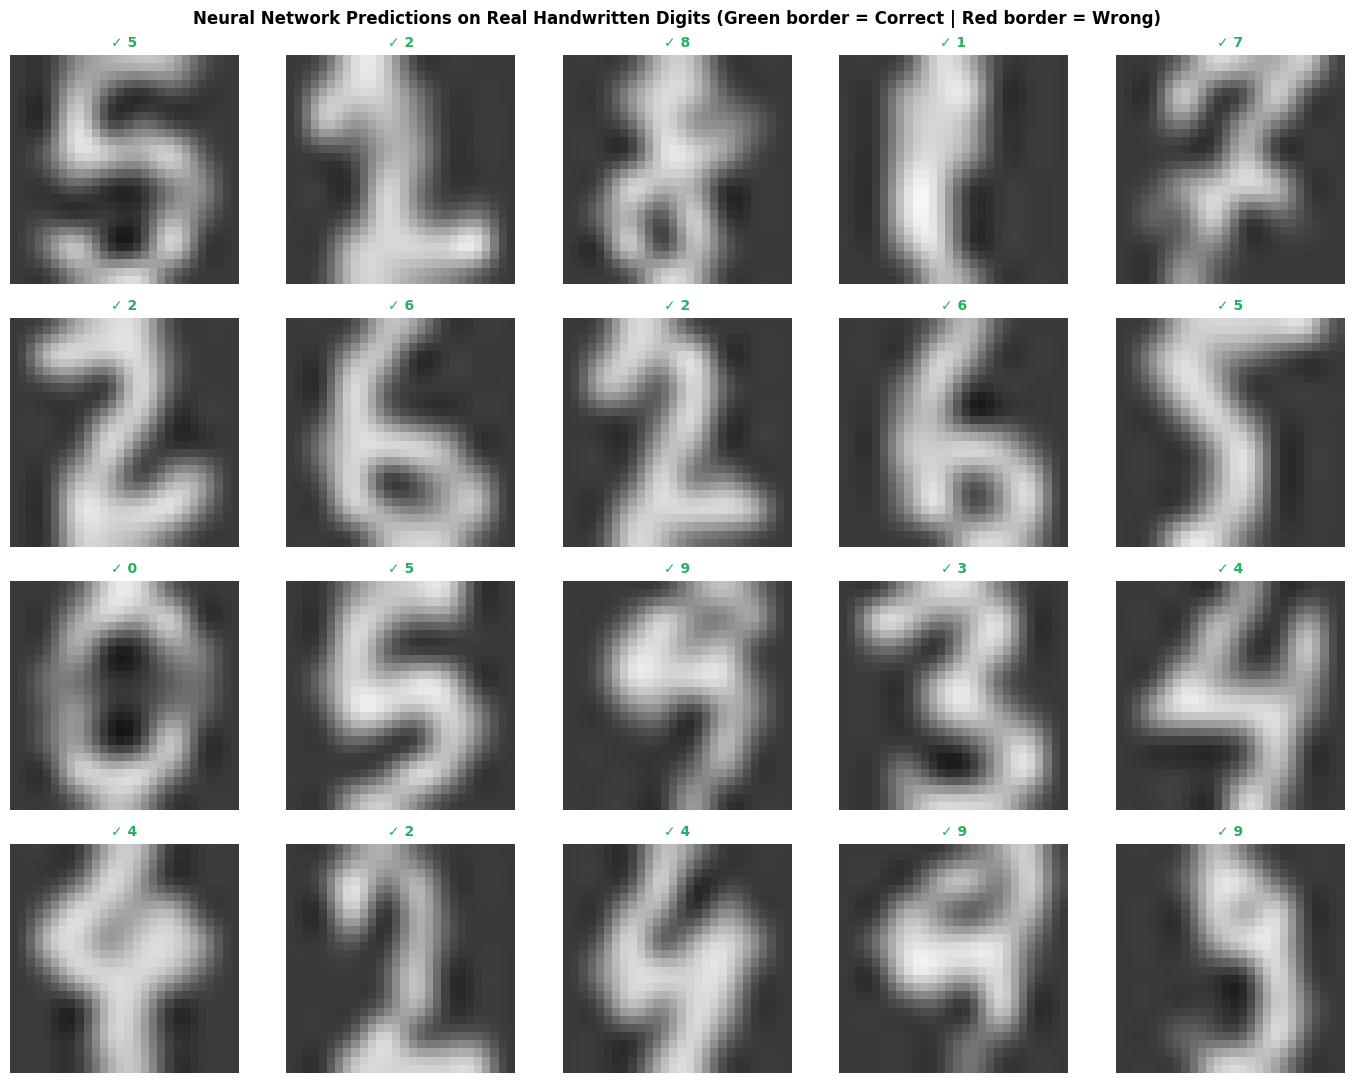

In these 20 displayed images:
  Correct : 20 (or see green borders above)
  Wrong   : 0 (see red borders)

Look at misclassified images — they often look ambiguous even to humans!
A '3' with closed loops resembles an '8'. A hasty '4' can look like '9'.


In [26]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 10 — DIGITS: VISUALISE PREDICTIONS ON REAL IMAGES
# ═══════════════════════════════════════════════════════════════════

# Show 20 test images with their predictions
# Green border = correct, Red border = wrong
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle(
    'Neural Network Predictions on Real Handwritten Digits '
    '(Green border = Correct | Red border = Wrong)',
    fontsize=12, fontweight='bold'
)

for i, ax in enumerate(axes.flatten()):
    # Display the actual image
    ax.imshow(X_te[i], cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

    predicted = y_pred[i]
    actual    = y_te[i]
    correct   = (predicted == actual)
    color     = '#27AE60' if correct else '#E74C3C'
    label     = f'✓ {actual}' if correct else f'P:{predicted} A:{actual}'

    ax.set_title(label, fontsize=10, color=color, fontweight='bold')

    # Coloured border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('tmp/digit_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

n_correct = np.sum(y_pred == y_te)
print(f"In these 20 displayed images:")
print(f"  Correct : {min(n_correct, 20)} (or see green borders above)")
print(f"  Wrong   : {max(20 - n_correct, 0)} (see red borders)")
print()
print("Look at misclassified images — they often look ambiguous even to humans!")
print("A '3' with closed loops resembles an '8'. A hasty '4' can look like '9'.")


---
## 🏥 Section 5 · Dropout and Binary Classification — Breast Cancer

### The Overfitting Problem

When a neural network is too large or trained too long, it **memorises** the training data instead of learning general patterns. Like a student who memorises exam questions rather than understanding the subject.

Signs of overfitting in learning curves:
```
Training accuracy  : 99%  ← very high
Validation accuracy: 75%  ← much lower
Gap                : 24%  ← OVERFITTING!
```

### Dropout: The Regularisation Technique

**Dropout** randomly "switches off" a fraction of neurons during each training step:
```
Without Dropout:                With Dropout(0.3):
  ●──●──●──●                    ●──✗──●──●   ← 30% neurons disabled (random each batch)
  ●──●──●──●    training →      ✗──●──✗──●
  ●──●──●──●                    ●──●──●──✗

At test time: ALL neurons active, but their outputs are scaled down.
```

**Why it prevents overfitting:** Each training step, different neurons are disabled. The network cannot rely on any specific neuron — it must learn redundant representations. Like a team that trains with random members absent — everyone must know everyone's job.

### Binary Classification — The Task

Breast cancer diagnosis: is the tumour **malignant (0)** or **benign (1)**?
- Output: single neuron with **sigmoid** activation → probability between 0 and 1
- Loss: `binary_crossentropy`
- Threshold: if output > 0.5 → predict benign; if output ≤ 0.5 → predict malignant

In [27]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 11 — BINARY CLASSIFICATION WITH DROPOUT: BREAST CANCER
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Data preparation
# ─────────────────────────────────────────────────────────────────
X_c = cancer.data.astype('float32')    # (569, 30) — 30 clinical features
y_c = cancer.target.astype('float32')  # binary: 0=malignant, 1=benign

# Train/test split with stratification (important for imbalanced classes)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# StandardScaler: normalise features to mean=0, std=1
# Fit ONLY on training data — never fit on test data (data leakage!)
scaler_c = StandardScaler()
X_c_tr_sc = scaler_c.fit_transform(X_c_tr).astype('float32')
X_c_te_sc = scaler_c.transform(X_c_te).astype('float32')

print("BREAST CANCER DATA PREPARATION:")
print(f"  Training: {X_c_tr_sc.shape} | Test: {X_c_te_sc.shape}")
print(f"  Feature range after scaling: {X_c_tr_sc.min():.2f} to {X_c_tr_sc.max():.2f}")
print(f"  Class distribution in training:")
print(f"    malignant (0): {np.sum(y_c_tr==0):.0f}  |  benign (1): {np.sum(y_c_tr==1):.0f}")
print()

# ─────────────────────────────────────────────────────────────────
# BUILD the model with Dropout layers
# ─────────────────────────────────────────────────────────────────
tf.random.set_seed(42)

cancer_model = Sequential([
    keras.Input(shape=(30,)),           # 30 input features

    # First hidden layer: 128 neurons
    layers.Dense(128, activation='relu', name='dense_1'),
    # Dropout(0.3) = randomly disable 30% of the 128 neurons each training step
    # During testing: all neurons active, outputs scaled by 0.7
    layers.Dropout(0.3, name='dropout_1'),

    # Second hidden layer: 64 neurons
    layers.Dense(64, activation='relu', name='dense_2'),
    # Dropout(0.3) again — regularise this layer too
    layers.Dropout(0.3, name='dropout_2'),

    # Third hidden layer: 32 neurons
    layers.Dense(32, activation='relu', name='dense_3'),

    # OUTPUT LAYER: 1 neuron (binary: malignant vs benign)
    # sigmoid: maps any number to (0, 1) range = probability of being benign
    # If output > 0.5 → predict benign (1)
    # If output ≤ 0.5 → predict malignant (0)
    layers.Dense(1, activation='sigmoid', name='output'),
])

# COMPILE with binary classification settings
cancer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    # Smaller learning rate (0.0005 vs 0.001) — medical data, be careful
    loss='binary_crossentropy',
    # Correct loss for binary classification (two classes, sigmoid output)
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
    # Track both accuracy AND AUC (Area Under ROC Curve)
    # AUC is better than accuracy for imbalanced medical datasets
)

print("CANCER MODEL ARCHITECTURE:")
print()
cancer_model.summary()
print()

# TRAIN
print("Training with Dropout regularisation...")
cancer_history = cancer_model.fit(
    X_c_tr_sc, y_c_tr,
    epochs=80,
    batch_size=32,
    validation_split=0.15,
    verbose=0                  # silent training — we'll plot the curves
)

# EVALUATE
test_loss, test_acc, test_auc = cancer_model.evaluate(X_c_te_sc, y_c_te, verbose=0)
print()
print("BREAST CANCER NEURAL NETWORK RESULTS:")
print(f"  Test accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"  Test AUC      : {test_auc:.4f} (1.0=perfect, 0.5=random)")
print(f"  Test loss     : {test_loss:.4f}")


BREAST CANCER DATA PREPARATION:
  Training: (455, 30) | Test: (114, 30)
  Feature range after scaling: -2.72 to 11.66
  Class distribution in training:
    malignant (0): 170  |  benign (1): 285

CANCER MODEL ARCHITECTURE:



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)


Training with Dropout regularisation...

BREAST CANCER NEURAL NETWORK RESULTS:
  Test accuracy : 0.9474 (94.7%)
  Test AUC      : 0.9856 (1.0=perfect, 0.5=random)
  Test loss     : 0.1613


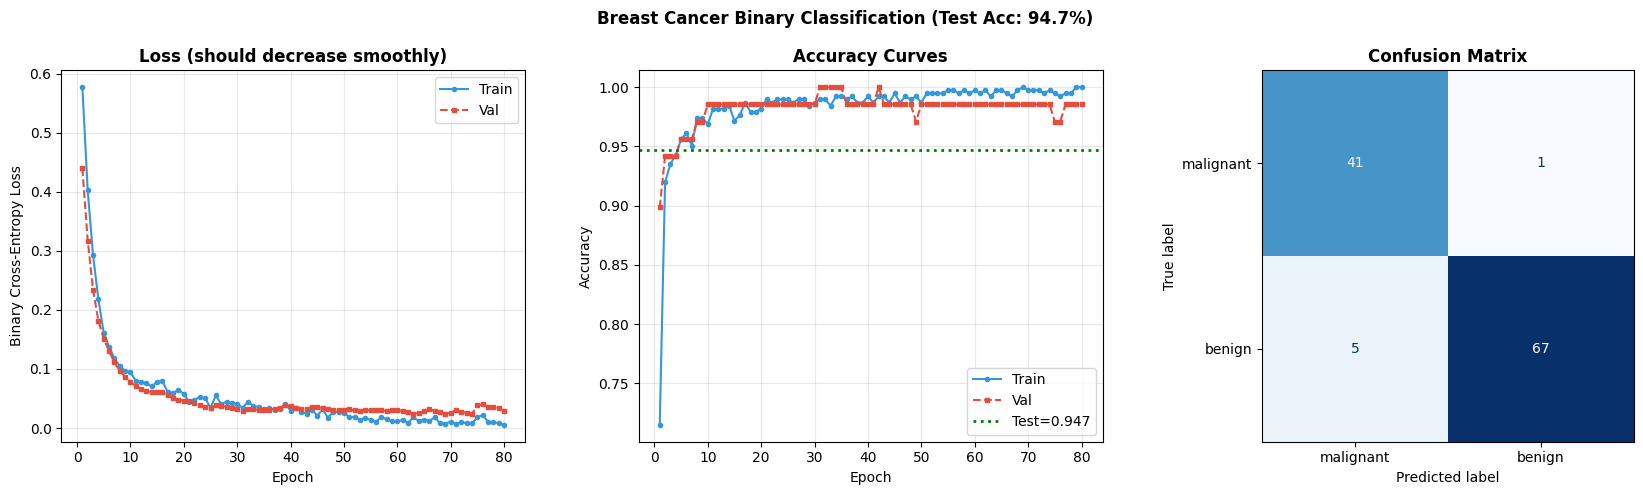

DETAILED CLASSIFICATION REPORT:

              precision    recall  f1-score   support

   malignant       0.89      0.98      0.93        42
      benign       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

Malignant Recall (most critical): 0.9762
  → The model catches 97.6% of actual cancer cases
  → It misses 2.4% of cancers (False Negatives)

DROPOUT EFFECT: Compare train vs val curves.
  Without Dropout: val accuracy would drop far below train accuracy.
  With Dropout: curves stay close together = better generalisation.


In [28]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 12 — CANCER MODEL: DETAILED EVALUATION
# ═══════════════════════════════════════════════════════════════════

# Get predictions
# model.predict() returns probabilities (float between 0 and 1)
y_c_proba = cancer_model.predict(X_c_te_sc, verbose=0).flatten()
# Convert probabilities to binary predictions using threshold 0.5
y_c_pred  = (y_c_proba > 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Breast Cancer Binary Classification (Test Acc: {test_acc*100:.1f}%)',
    fontsize=12, fontweight='bold'
)

hist_c = cancer_history.history
ep_c   = range(1, len(hist_c['loss']) + 1)

# Left: Loss curves
axes[0].plot(ep_c, hist_c['loss'], 'o-', color='#3498DB', lw=1.5, ms=3, label='Train')
axes[0].plot(ep_c, hist_c['val_loss'], 's--', color='#E74C3C', lw=1.5, ms=3, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Loss (should decrease smoothly)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Middle: Accuracy curves
axes[1].plot(ep_c, hist_c['accuracy'], 'o-', color='#3498DB', lw=1.5, ms=3, label='Train')
axes[1].plot(ep_c, hist_c['val_accuracy'], 's--', color='#E74C3C', lw=1.5, ms=3, label='Val')
axes[1].axhline(test_acc, color='green', ls=':', lw=2, label=f'Test={test_acc:.3f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Right: Confusion matrix
cm_c = confusion_matrix(y_c_te.astype(int), y_c_pred)
ConfusionMatrixDisplay(cm_c, display_labels=cancer.target_names).plot(
    ax=axes[2], cmap='Blues', colorbar=False
)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('tmp/cancer_nn_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("DETAILED CLASSIFICATION REPORT:")
print()
print(classification_report(
    y_c_te.astype(int), y_c_pred, target_names=cancer.target_names
))

# Critical medical metrics
from sklearn.metrics import recall_score, precision_score
mal_recall = recall_score(y_c_te.astype(int), y_c_pred, pos_label=0)
print(f"Malignant Recall (most critical): {mal_recall:.4f}")
print(f"  → The model catches {mal_recall*100:.1f}% of actual cancer cases")
print(f"  → It misses {(1-mal_recall)*100:.1f}% of cancers (False Negatives)")
print()
print("DROPOUT EFFECT: Compare train vs val curves.")
print("  Without Dropout: val accuracy would drop far below train accuracy.")
print("  With Dropout: curves stay close together = better generalisation.")


---
## 📈 Section 6 · Regression with Neural Networks — Diabetes Dataset

### Neural Network Regression vs Classification

| | Classification | Regression |
|--|----------------|-----------|
| **Output neuron activation** | `softmax` (multi-class) or `sigmoid` (binary) | `linear` (no activation) |
| **Loss function** | `crossentropy` | `mean_squared_error` or `mean_absolute_error` |
| **Output interpretation** | Probability of each class | A continuous predicted number |
| **Evaluation metric** | Accuracy, F1, AUC | MAE, RMSE, R² |

### Why `linear` Activation for Regression?

The output neuron in regression needs to produce any real number (not 0 to 1).
`linear` means: just output the weighted sum directly — no squashing function.

```
Output neuron (regression):   output = w₁×h₁ + w₂×h₂ + ... + bias  → any number
Output neuron (sigmoid):       output = 1/(1+e^(−z))                 → 0 to 1 only
```

### What We're Predicting

Diabetes disease progression score: ranges from 25 to 346.
The neural network will predict a single continuous number for each patient.

In [29]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 13 — REGRESSION: DIABETES DISEASE PROGRESSION PREDICTION
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Data preparation
# ─────────────────────────────────────────────────────────────────
X_d = diabetes.data.astype('float32')   # (442, 10) — already normalised by sklearn
y_d = diabetes.target.astype('float32') # continuous: 25.0 to 346.0

X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)
# No stratify for regression — stratify is for classification only

print("DIABETES DATASET:")
print(f"  Training: {X_d_tr.shape} | Test: {X_d_te.shape}")
print(f"  Target range: {y_d_tr.min():.1f} to {y_d_tr.max():.1f}")
print(f"  Target mean:  {y_d_tr.mean():.1f} ± {y_d_tr.std():.1f}")
print()
print("NOTE: Diabetes features are already normalised by sklearn (mean≈0, std≈1)")
print("      No additional scaling needed for the features.")
print("      The TARGET (disease progression score) is NOT normalised")
print("      — regression models can handle this naturally.")
print()

# ─────────────────────────────────────────────────────────────────
# BUILD the regression model
# ─────────────────────────────────────────────────────────────────
tf.random.set_seed(42)

diabetes_model = Sequential([
    keras.Input(shape=(10,)),          # 10 clinical features

    # Hidden layers for regression work the same as classification
    # More neurons = more capacity to learn complex patterns
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dropout(0.2, name='dropout_1'),     # mild dropout for regression

    layers.Dense(64, activation='relu', name='dense_2'),
    layers.Dropout(0.2, name='dropout_2'),

    layers.Dense(32, activation='relu', name='dense_3'),

    # OUTPUT LAYER — KEY DIFFERENCE FROM CLASSIFICATION:
    # 1 neuron (we predict ONE number per patient)
    # activation='linear' — no squashing! Output can be any real number.
    # If we used sigmoid here, output would be 0–1 but we need 25–346!
    layers.Dense(1, activation='linear', name='output_regression'),
])

# COMPILE with regression settings
diabetes_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',  # MSE: mean of (predicted - actual)²
    # MSE penalises large errors heavily (squaring amplifies them)
    metrics=['mae']
    # MAE (Mean Absolute Error): average |predicted - actual|
    # More interpretable than MSE — same units as the target (disease score)
)

print("REGRESSION MODEL ARCHITECTURE:")
diabetes_model.summary()
print()

# TRAIN
diab_history = diabetes_model.fit(
    X_d_tr, y_d_tr,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    verbose=0
)

# EVALUATE
mse, mae_val = diabetes_model.evaluate(X_d_te, y_d_te, verbose=0)
rmse = np.sqrt(mse)

# Get predictions
y_d_pred = diabetes_model.predict(X_d_te, verbose=0).flatten()

# Compute R² score
r2 = r2_score(y_d_te, y_d_pred)

print("DIABETES REGRESSION RESULTS:")
print(f"  Test MAE     : {mae_val:.2f} (average prediction error in disease-score units)")
print(f"  Test RMSE    : {rmse:.2f} (penalises large errors more than MAE)")
print(f"  Test R²      : {r2:.4f} (fraction of variance explained)")
print(f"    → Model explains {r2*100:.1f}% of variance in disease progression")
print()
print("COMPARISON WITH sklearn LASSO (from sklearn masterclass):")
print("  sklearn Lasso: R²≈0.47, MAE≈42.85")
print(f"  TF Neural Net: R²={r2:.2f}, MAE={mae_val:.2f}")
print("  Deep learning doesn't always beat simpler models on small tabular datasets!")


DIABETES DATASET:
  Training: (353, 10) | Test: (89, 10)
  Target range: 25.0 to 346.0
  Target mean:  153.7 ± 78.0

NOTE: Diabetes features are already normalised by sklearn (mean≈0, std≈1)
      No additional scaling needed for the features.
      The TARGET (disease progression score) is NOT normalised
      — regression models can handle this naturally.

REGRESSION MODEL ARCHITECTURE:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_regression (Dense)       │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)


DIABETES REGRESSION RESULTS:
  Test MAE     : 43.02 (average prediction error in disease-score units)
  Test RMSE    : 54.48 (penalises large errors more than MAE)
  Test R²      : 0.4398 (fraction of variance explained)
    → Model explains 44.0% of variance in disease progression

COMPARISON WITH sklearn LASSO (from sklearn masterclass):
  sklearn Lasso: R²≈0.47, MAE≈42.85
  TF Neural Net: R²=0.44, MAE=43.02
  Deep learning doesn't always beat simpler models on small tabular datasets!


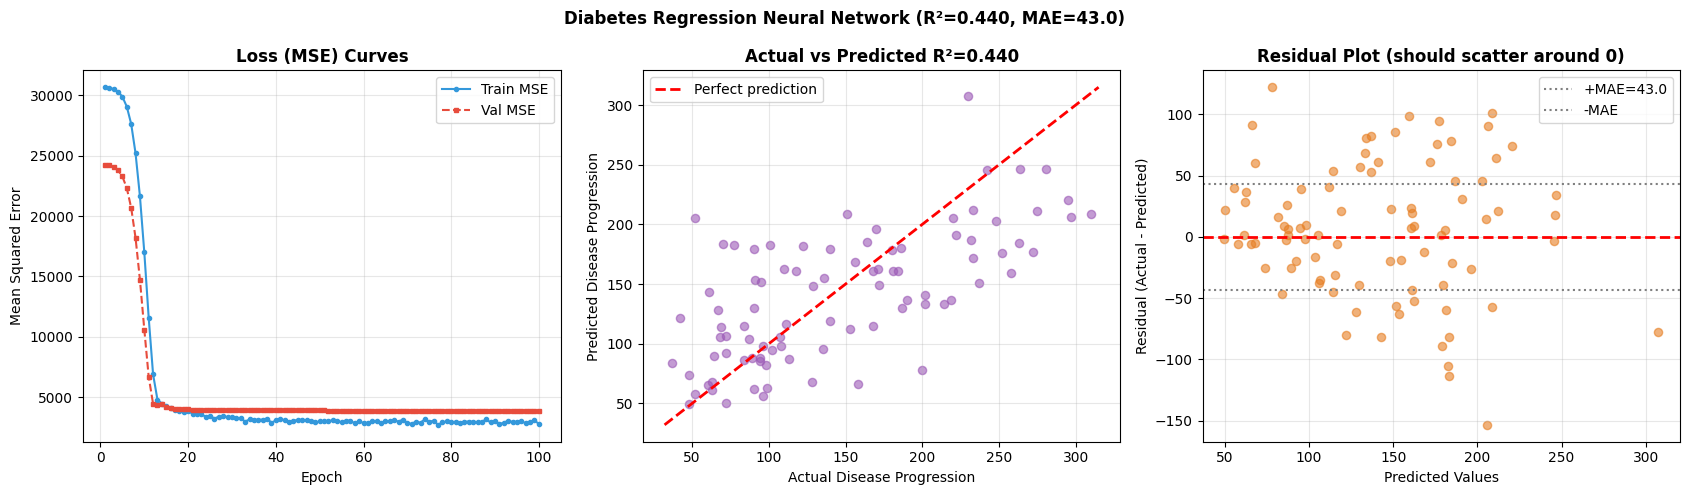

RESIDUAL PLOT INTERPRETATION:
  Random scatter around 0 → model errors are random (good!)
  Curved pattern → model misses non-linear relationships
  Fan shape (widening) → errors grow with predicted value


In [30]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 14 — REGRESSION: EVALUATION PLOTS
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Diabetes Regression Neural Network (R²={r2:.3f}, MAE={mae_val:.1f})',
    fontsize=12, fontweight='bold'
)

hist_d = diab_history.history
ep_d   = range(1, len(hist_d['loss']) + 1)

# Left: Loss (MSE) curves
axes[0].plot(ep_d, hist_d['loss'], 'o-', color='#3498DB', lw=1.5, ms=3, label='Train MSE')
axes[0].plot(ep_d, hist_d['val_loss'], 's--', color='#E74C3C', lw=1.5, ms=3, label='Val MSE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Loss (MSE) Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Middle: Actual vs Predicted scatter plot
axes[1].scatter(y_d_te, y_d_pred, alpha=0.6, color='#9B59B6', s=35)
lims = [min(y_d_te.min(), y_d_pred.min()) - 5,
        max(y_d_te.max(), y_d_pred.max()) + 5]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Disease Progression')
axes[1].set_ylabel('Predicted Disease Progression')
axes[1].set_title(f'Actual vs Predicted R²={r2:.3f}', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Right: Residuals
residuals = y_d_te - y_d_pred
axes[2].scatter(y_d_pred, residuals, alpha=0.6, color='#E67E22', s=35)
axes[2].axhline(0, color='red', ls='--', lw=2)
axes[2].axhline(mae_val, color='gray', ls=':', lw=1.5, label=f'+MAE={mae_val:.1f}')
axes[2].axhline(-mae_val, color='gray', ls=':', lw=1.5, label=f'-MAE')
axes[2].set_xlabel('Predicted Values'); axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residual Plot (should scatter around 0)', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tmp/diabetes_nn_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("RESIDUAL PLOT INTERPRETATION:")
print("  Random scatter around 0 → model errors are random (good!)")
print("  Curved pattern → model misses non-linear relationships")
print("  Fan shape (widening) → errors grow with predicted value")


---
## 🖼️ Section 7 · Convolutional Neural Networks (CNNs) — Image Recognition

### Why CNNs for Images?

A Dense layer connects EVERY input to EVERY neuron. For a 28×28 image:
- 784 inputs × 256 neurons = 200,960 parameters in just ONE layer!
- This doesn't scale: a 224×224 colour image × 1000 neurons = 150 million parameters in one layer.

More importantly, Dense layers don't understand **spatial structure** — they treat pixel (0,0) and pixel (27,27) as completely unrelated inputs.

**CNNs solve both problems:**

### The Convolution Operation

A **filter** (or kernel) is a small matrix (e.g. 3×3) that slides across the image:

```
IMAGE PATCH:      3×3 FILTER:     MULTIPLICATION + SUM:
  0  0  5          −1  0  1         0×(−1) + 0×0 + 5×1
  0 13 15      ×    0  0  0    =   + 0×0 + 13×0 + 15×0
  0  3 15           1  0 −1        + 0×1 + 3×0 + 15×(−1)
                                  = 5 + 0 − 15 = −10
```

The filter slides across every position in the image, producing a **feature map**.
Different filters detect different features: edges, curves, corners, textures.

**The network LEARNS the filter values** — it discovers which filters are useful!

### CNN Architecture Components

```
INPUT IMAGE (28×28×1)
  ↓
Conv2D(32 filters, 3×3) → 32 feature maps (one per filter)
  ↓
MaxPooling2D(2×2) → reduces each feature map from 28×28 to 14×14
  ↓
Conv2D(64 filters, 3×3) → 64 more complex feature maps
  ↓
MaxPooling2D(2×2) → reduces to 7×7
  ↓
Flatten → convert 7×7×64 = 3136 values to 1D
  ↓
Dense(128) → fully connected classification head
  ↓
Dense(10, softmax) → 10 class probabilities
```

### MaxPooling

`MaxPooling2D(2×2)` divides the feature map into 2×2 blocks and keeps only the MAXIMUM value:
```
FEATURE MAP:    AFTER MaxPool(2×2):
 1  3  2  4      3  4      ← max of top-left 2×2 block, max of top-right
 0  2  1  3  →   2  8      ← max of bottom-left 2×2 block, etc.
 5  2  8  1
 1  0  3  2
```

Benefits: reduces image size (less computation), provides translation invariance (pattern detected regardless of exact position).

In [31]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 15 — CNN: DATA PREPARATION FOR 2D IMAGES
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# CNNs need 4D input: (batch_size, height, width, channels)
# channels=1 for greyscale, channels=3 for colour (RGB)
# ─────────────────────────────────────────────────────────────────

# Reshape from (N, 28, 28) to (N, 28, 28, 1)
# The final 1 = greyscale (one colour channel)
# Conv2D requires this channel dimension even for greyscale images
X_cnn_tr = X_tr_norm[..., np.newaxis]   # (N, 28, 28) → (N, 28, 28, 1)
X_cnn_te = X_te_norm[..., np.newaxis]   # same for test set

print("CNN INPUT SHAPE REQUIREMENTS:")
print(f"  Dense model input : {X_tr_norm.shape} (N, 28, 28) — flat images")
print(f"  CNN input         : {X_cnn_tr.shape} (N, 28, 28, 1) — 2D with channel dim")
print()
print("WHY THE EXTRA DIMENSION?")
print("  Conv2D layers convolve over (height, width, channels)")
print("  Greyscale images: 1 channel (one intensity value per pixel)")
print("  RGB colour images: 3 channels (red, green, blue per pixel)")
print("  Having the explicit channel dimension makes code work for both types")
print()
print(f"Image value range: {X_cnn_tr.min():.3f} to {X_cnn_tr.max():.3f}")
print(f"Labels: {np.unique(y_tr)} (digits 0–9, same as before)")


CNN INPUT SHAPE REQUIREMENTS:
  Dense model input : (1437, 28, 28) (N, 28, 28) — flat images
  CNN input         : (1437, 28, 28, 1) (N, 28, 28, 1) — 2D with channel dim

WHY THE EXTRA DIMENSION?
  Conv2D layers convolve over (height, width, channels)
  Greyscale images: 1 channel (one intensity value per pixel)
  RGB colour images: 3 channels (red, green, blue per pixel)
  Having the explicit channel dimension makes code work for both types

Image value range: 0.000 to 1.000
Labels: [0 1 2 3 4 5 6 7 8 9] (digits 0–9, same as before)


In [32]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 16 — CNN: BUILD THE CONVOLUTIONAL NEURAL NETWORK
# ═══════════════════════════════════════════════════════════════════

tf.random.set_seed(42)

cnn_model = Sequential([

    # INPUT: 28×28 greyscale images (28 height, 28 width, 1 channel)
    keras.Input(shape=(28, 28, 1)),

    # ─────── CONVOLUTIONAL BLOCK 1 ───────────────────────────────
    # Conv2D(32, (3,3)):
    #   32 = number of filters to learn (32 different pattern detectors)
    #   (3,3) = each filter looks at a 3×3 pixel neighbourhood
    #   activation='relu' = apply ReLU after each convolution
    #   padding='same' = pad edges so output is same size as input (28×28)
    # Output shape: (28, 28, 32) — 32 feature maps, each 28×28
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),

    # MaxPooling2D((2,2)):
    #   Divide each feature map into 2×2 blocks, keep the maximum
    #   Reduces size from 28×28 to 14×14
    #   Benefits: fewer parameters, translation invariance
    # Output shape: (14, 14, 32)
    layers.MaxPooling2D((2, 2), name='pool1'),

    # ─────── CONVOLUTIONAL BLOCK 2 ───────────────────────────────
    # 64 filters: learns more complex combinations of Block 1 features
    # Block 1 might detect edges → Block 2 detects corners and curves
    # Output after Conv2D: (14, 14, 64)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    # Output after MaxPool: (7, 7, 64)
    layers.MaxPooling2D((2, 2), name='pool2'),

    # ─────── CONVOLUTIONAL BLOCK 3 ───────────────────────────────
    # 128 filters: even more complex features
    # Output after Conv2D: (7, 7, 128) — same size (no pooling here)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),

    # ─────── CLASSIFICATION HEAD ─────────────────────────────────
    # Flatten: convert (7, 7, 128) = 6,272 values to 1D
    # Required bridge between Conv layers and Dense layers
    layers.Flatten(name='flatten'),

    # Dropout before the fully connected layer
    # 50% dropout is common in the classification head of CNNs
    layers.Dropout(0.5, name='dropout'),

    # Dense classification layer
    layers.Dense(256, activation='relu', name='dense'),

    # OUTPUT: 10 classes (digits 0–9), softmax probabilities
    layers.Dense(10, activation='softmax', name='output'),
])

# COMPILE
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN ARCHITECTURE SUMMARY:")
print()
cnn_model.summary()
print()
print("PARAMETER ANALYSIS:")
print("  CNN has fewer parameters than a deep Dense network on the same image!")
print("  Reason: each filter's 9 weights (3×3) are SHARED across ALL positions in the image")
print("  Filter weight sharing = massive parameter efficiency for images")
print()
print("Training CNN (this takes ~1–2 minutes)...")
cnn_history = cnn_model.fit(
    X_cnn_tr, y_tr,
    epochs=20,
    batch_size=64,         # larger batch for CNN (more data per step)
    validation_split=0.15,
    verbose=1
)


CNN ARCHITECTURE SUMMARY:



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,130 (6.49 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)


PARAMETER ANALYSIS:
  CNN has fewer parameters than a deep Dense network on the same image!
  Reason: each filter's 9 weights (3×3) are SHARED across ALL positions in the image
  Filter weight sharing = massive parameter efficiency for images

Training CNN (this takes ~1–2 minutes)...
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.4734 - loss: 1.6509 - val_accuracy: 0.7870 - val_loss: 0.6731
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8935 - loss: 0.3379 - val_accuracy: 0.9167 - val_loss: 0.2718
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9369 - loss: 0.1750 - val_accuracy: 0.9306 - val_loss: 0.2335
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9566 - loss: 0.1306 - val_accuracy: 0.9444 - val_loss: 0.1637
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9672 - loss: 0.1070 - val_accuracy: 0.9630 - val_loss: 0.1614
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9771 - loss: 

CNN vs DENSE NETWORK COMPARISON:
  Dense Network: 0.9474 (94.7%)
  CNN          : 0.9694 (96.9%)



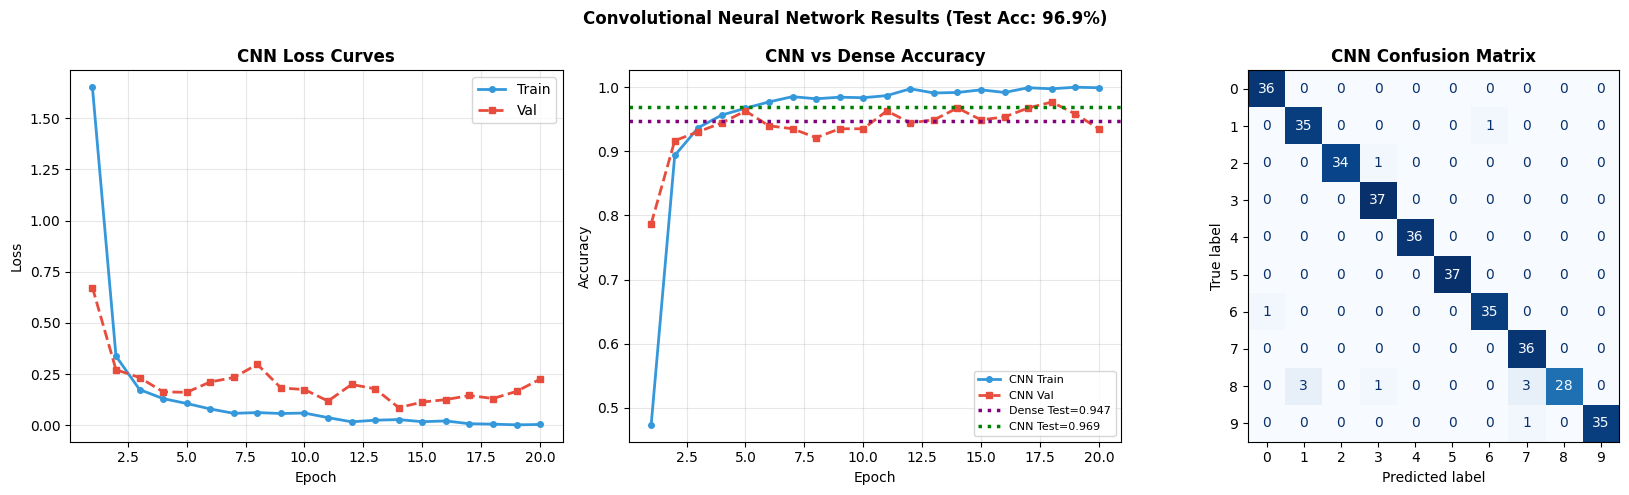

KEY CNN LESSONS:
  1. CNNs learn spatial features — edges, curves, textures — automatically
  2. Max pooling provides translation invariance (pattern in any position)
  3. Deeper CNNs (more Conv blocks) detect more abstract features
  4. For REAL images (MNIST, CIFAR-10), CNNs dramatically outperform Dense networks
  5. Our digits: CNN 96.9% vs Dense 94.7%


In [33]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 17 — CNN: EVALUATE AND COMPARE WITH DENSE MODEL
# ═══════════════════════════════════════════════════════════════════

cnn_loss, cnn_acc = cnn_model.evaluate(X_cnn_te, y_te, verbose=0)
dense_acc = test_acc  # from Cell 9

y_cnn_proba = cnn_model.predict(X_cnn_te, verbose=0)
y_cnn_pred  = np.argmax(y_cnn_proba, axis=1)

print("CNN vs DENSE NETWORK COMPARISON:")
print(f"  Dense Network: {dense_acc:.4f} ({dense_acc*100:.1f}%)")
print(f"  CNN          : {cnn_acc:.4f} ({cnn_acc*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Convolutional Neural Network Results (Test Acc: {cnn_acc*100:.1f}%)',
    fontsize=12, fontweight='bold'
)

hist_cnn = cnn_history.history
ep_cnn   = range(1, len(hist_cnn['loss']) + 1)

axes[0].plot(ep_cnn, hist_cnn['loss'], 'o-', color='#3498DB', lw=2, ms=4, label='Train')
axes[0].plot(ep_cnn, hist_cnn['val_loss'], 's--', color='#E74C3C', lw=2, ms=4, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN Loss Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_cnn, hist_cnn['accuracy'], 'o-', color='#3498DB', lw=2, ms=4, label='CNN Train')
axes[1].plot(ep_cnn, hist_cnn['val_accuracy'], 's--', color='#E74C3C', lw=2, ms=4, label='CNN Val')
axes[1].axhline(dense_acc, color='purple', ls=':', lw=2.5, label=f'Dense Test={dense_acc:.3f}')
axes[1].axhline(cnn_acc, color='green', ls=':', lw=2.5, label=f'CNN Test={cnn_acc:.3f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('CNN vs Dense Accuracy', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

cm_cnn = confusion_matrix(y_te, y_cnn_pred)
ConfusionMatrixDisplay(cm_cnn, display_labels=list(range(10))).plot(
    ax=axes[2], cmap='Blues', colorbar=False
)
axes[2].set_title('CNN Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('tmp/cnn_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("KEY CNN LESSONS:")
print("  1. CNNs learn spatial features — edges, curves, textures — automatically")
print("  2. Max pooling provides translation invariance (pattern in any position)")
print("  3. Deeper CNNs (more Conv blocks) detect more abstract features")
print("  4. For REAL images (MNIST, CIFAR-10), CNNs dramatically outperform Dense networks")
print(f"  5. Our digits: CNN {cnn_acc*100:.1f}% vs Dense {dense_acc*100:.1f}%")


---
## 🔤 Section 8 · Recurrent Networks & LSTM — Sequence Processing

### Why Recurrent Networks?

Dense and CNN layers are **stateless** — each input is processed independently.
But some data has **order and context**:
- Text: "The food was not bad" — "not bad" means good; order matters!
- Time series: today's temperature depends on yesterday's

**Recurrent Neural Networks (RNNs)** process sequences by maintaining a **hidden state** that carries information from previous time steps.

### The LSTM Cell

**Long Short-Term Memory (LSTM)** is the most popular RNN variant. It solves the "vanishing gradient" problem of simple RNNs:

```
LSTM cell at time step t:
  Input: xₜ (current input) + hₜ₋₁ (hidden state from previous step)
  ↓
  FORGET GATE:  how much of the old memory to forget?  (0=forget all, 1=keep all)
  INPUT GATE:   what new information to add to memory?
  OUTPUT GATE:  what to output based on the memory?
  ↓
  Output: hₜ (new hidden state passed to next step)
         cₜ (cell state — the long-term memory)
```

### Applying LSTM to Tabular Data

Wine has 13 chemical features. We can reshape this as a sequence:
- Treat each feature as a "time step" in a sequence of length 13
- LSTM processes feature 1, then feature 2, ..., then feature 13
- The final hidden state summarises all 13 features

This demonstrates the LSTM architecture even without true sequential data.

In [34]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 18 — LSTM: SEQUENCE-STYLE CLASSIFICATION ON WINE DATA
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Prepare Wine data as a sequence
# ─────────────────────────────────────────────────────────────────
X_w = wine.data.astype('float32')    # (178, 13) — 13 chemical features
y_w = wine.target                    # (178,) — classes 0, 1, 2

# Standard scaling
X_w_tr, X_w_te, y_w_tr, y_w_te = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42, stratify=y_w
)
scaler_w  = StandardScaler()
X_w_tr_sc = scaler_w.fit_transform(X_w_tr).astype('float32')
X_w_te_sc = scaler_w.transform(X_w_te).astype('float32')

# RESHAPE for LSTM: (samples, time_steps, features_per_step)
# We treat each of the 13 features as a separate "time step"
# Each time step has 1 value: the chemical measurement
# So shape becomes (N, 13, 1): N samples, 13 time steps, 1 value per step
X_w_tr_seq = X_w_tr_sc.reshape(-1, 13, 1)   # (N, 13, 1)
X_w_te_seq = X_w_te_sc.reshape(-1, 13, 1)

print("WINE DATA PREPARED AS SEQUENCES FOR LSTM:")
print(f"  Original shape: {X_w_tr_sc.shape}  (N samples × 13 features)")
print(f"  LSTM shape    : {X_w_tr_seq.shape}  (N samples × 13 time steps × 1 value)")
print()
print("LSTM reads the 13 chemical features ONE AT A TIME:")
print("  Step 1: read alcohol value")
print("  Step 2: read malic_acid value (remembers step 1)")
print("  Step 3: read ash value (remembers steps 1–2)")
print("  ...")
print("  Step 13: read proline value (remembers all previous steps)")
print("  Output: classification based on the full sequence context")
print()

# ─────────────────────────────────────────────────────────────────
# BUILD the LSTM model
# ─────────────────────────────────────────────────────────────────
tf.random.set_seed(42)

lstm_model = Sequential([

    # INPUT: sequences of shape (13 time steps, 1 value per step)
    keras.Input(shape=(13, 1)),

    # FIRST LSTM LAYER:
    # 64 = number of LSTM units (hidden state dimension)
    # return_sequences=True: pass the full sequence to the next LSTM
    # If return_sequences=False (default): only pass the FINAL hidden state
    # We use True here because we have a second LSTM layer
    layers.LSTM(64, return_sequences=True, name='lstm_1'),

    # DROPOUT between LSTM layers
    layers.Dropout(0.3, name='dropout_1'),

    # SECOND LSTM LAYER:
    # return_sequences=False: we only need the final hidden state
    # The final hidden state summarises the entire 13-step sequence
    layers.LSTM(32, return_sequences=False, name='lstm_2'),

    # DROPOUT for regularisation
    layers.Dropout(0.3, name='dropout_2'),

    # Dense layer before output
    layers.Dense(32, activation='relu', name='dense'),

    # OUTPUT: 3 wine classes, softmax probabilities
    layers.Dense(3, activation='softmax', name='output'),
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("LSTM MODEL ARCHITECTURE:")
lstm_model.summary()
print()

print("Training LSTM model on wine data...")
lstm_history = lstm_model.fit(
    X_w_tr_seq, y_w_tr,
    epochs=80,
    batch_size=16,       # small batch for small dataset (178 wines total)
    validation_split=0.15,
    verbose=0
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_w_te_seq, y_w_te, verbose=0)
y_lstm_pred = np.argmax(lstm_model.predict(X_w_te_seq, verbose=0), axis=1)

print()
print(f"LSTM Wine Classification Test Accuracy: {lstm_acc:.4f} ({lstm_acc*100:.1f}%)")
print()
print(classification_report(y_w_te, y_lstm_pred,
                             target_names=wine.target_names))


WINE DATA PREPARED AS SEQUENCES FOR LSTM:
  Original shape: (142, 13)  (N samples × 13 features)
  LSTM shape    : (142, 13, 1)  (N samples × 13 time steps × 1 value)

LSTM reads the 13 chemical features ONE AT A TIME:
  Step 1: read alcohol value
  Step 2: read malic_acid value (remembers step 1)
  Step 3: read ash value (remembers steps 1–2)
  ...
  Step 13: read proline value (remembers all previous steps)
  Output: classification based on the full sequence context

LSTM MODEL ARCHITECTURE:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 13, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,467 (119.01 KB)

 Trainable params: 30,467 (119.01 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model on wine data...

LSTM Wine Classification Test Accuracy: 0.9722 (97.2%)

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



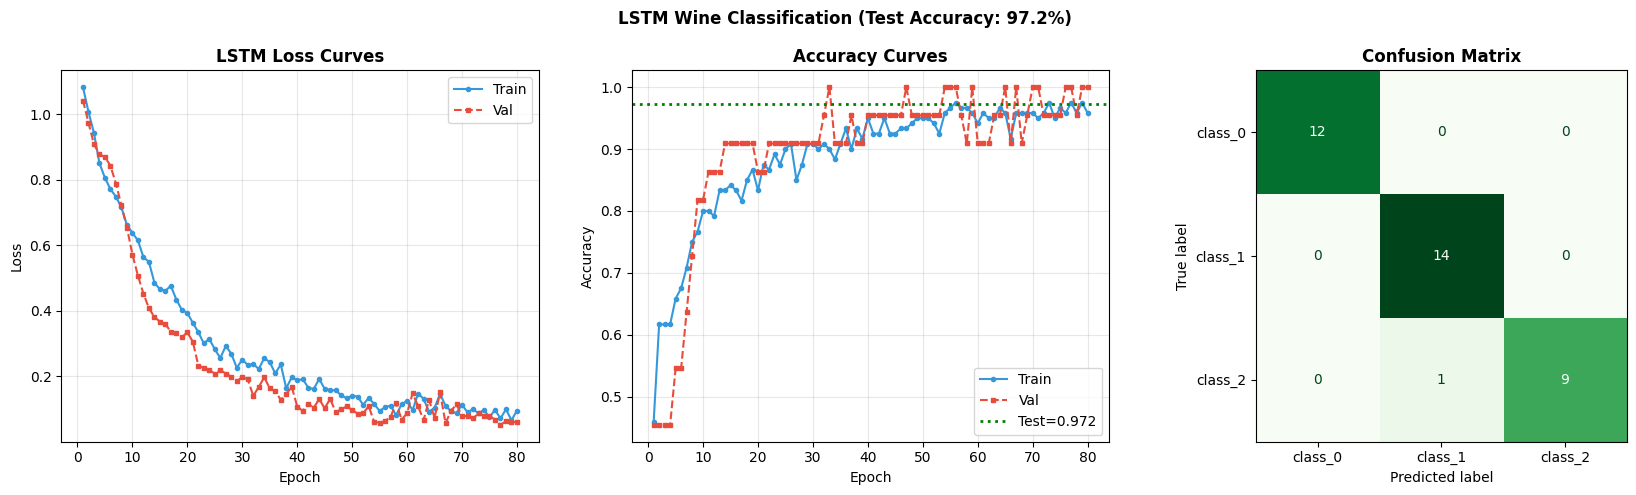

LSTM KEY CONCEPTS RECAP:

  return_sequences=True  → passes FULL sequence to next layer
  return_sequences=False → passes ONLY final hidden state (typical for classification)

  LSTM excels at:
    • Text classification (movie reviews, spam detection)
    • Time series (stock prices, sensor readings, ECG signals)
    • Speech recognition (audio as a time sequence)
    • Machine translation (sentence as a word sequence)

  For TRUE sequence data (text, audio), LSTM shows its real power!
  Here we used it on tabular wine data for demonstration — it still works!


In [35]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 19 — LSTM: RESULTS VISUALISATION
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'LSTM Wine Classification (Test Accuracy: {lstm_acc*100:.1f}%)',
    fontsize=12, fontweight='bold'
)

hist_l = lstm_history.history
ep_l   = range(1, len(hist_l['loss']) + 1)

# Loss curves
axes[0].plot(ep_l, hist_l['loss'], 'o-', color='#3498DB', lw=1.5, ms=3, label='Train')
axes[0].plot(ep_l, hist_l['val_loss'], 's--', color='#E74C3C', lw=1.5, ms=3, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('LSTM Loss Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(ep_l, hist_l['accuracy'], 'o-', color='#3498DB', lw=1.5, ms=3, label='Train')
axes[1].plot(ep_l, hist_l['val_accuracy'], 's--', color='#E74C3C', lw=1.5, ms=3, label='Val')
axes[1].axhline(lstm_acc, color='green', ls=':', lw=2, label=f'Test={lstm_acc:.3f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
cm_lstm = confusion_matrix(y_w_te, y_lstm_pred)
ConfusionMatrixDisplay(cm_lstm, display_labels=wine.target_names).plot(
    ax=axes[2], cmap='Greens', colorbar=False
)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('tmp/lstm_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("LSTM KEY CONCEPTS RECAP:")
print()
print("  return_sequences=True  → passes FULL sequence to next layer")
print("  return_sequences=False → passes ONLY final hidden state (typical for classification)")
print()
print("  LSTM excels at:")
print("    • Text classification (movie reviews, spam detection)")
print("    • Time series (stock prices, sensor readings, ECG signals)")
print("    • Speech recognition (audio as a time sequence)")
print("    • Machine translation (sentence as a word sequence)")
print()
print("  For TRUE sequence data (text, audio), LSTM shows its real power!")
print("  Here we used it on tabular wine data for demonstration — it still works!")


---
## 🎛️ Section 9 · Callbacks and Advanced Training Techniques

### What Are Callbacks?

**Callbacks** are functions that run automatically at specific points during training:
- At the end of each epoch
- When validation loss improves
- When training should stop early

They let you add intelligence to the training loop without modifying the `.fit()` call.

### Three Essential Callbacks

**1. EarlyStopping** — Stops training when improvement stops:
```python
EarlyStopping(monitor='val_loss', patience=10)
# If val_loss doesn't improve for 10 consecutive epochs → STOP TRAINING
# Why: prevents overfitting by stopping before the model memorises training data
# 'restore_best_weights=True' → roll back to the best epoch's weights
```

**2. ModelCheckpoint** — Saves the model automatically at its best point:
```python
ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
# Saves the model every time val_accuracy improves
# Ensures you always have the best version saved, not the final (possibly overfit) version
```

**3. ReduceLROnPlateau** — Reduces learning rate when training stalls:
```python
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
# If val_loss doesn't improve for 5 epochs → multiply learning rate by 0.5
# Why: small learning rate helps fine-tune once we're close to the minimum
```

### Batch Normalisation

Another powerful technique that goes alongside callbacks:
```
Without BatchNorm: each layer gets inputs with changing distribution → unstable training
With BatchNorm:    normalises each layer's inputs to mean≈0, std≈1 → faster, more stable
```

`BatchNormalization` can often replace Dropout for preventing overfitting.

In [36]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 20 — CALLBACKS: EARLY STOPPING, CHECKPOINT, AND LR REDUCTION
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Use Iris dataset for this demonstration
# ─────────────────────────────────────────────────────────────────
X_iris = iris.data.astype('float32')    # (150, 4)
y_iris = iris.target                    # (150,) — classes 0, 1, 2

X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
scaler_i  = StandardScaler()
X_i_tr_sc = scaler_i.fit_transform(X_i_tr).astype('float32')
X_i_te_sc = scaler_i.transform(X_i_te).astype('float32')

# ─────────────────────────────────────────────────────────────────
# DEFINE CALLBACKS
# ─────────────────────────────────────────────────────────────────
# 1. EarlyStopping: stop training when val_loss stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',         # which metric to watch
    patience=20,                # wait 20 epochs before stopping
    # patience is important: too small = stop too early; too large = wastes time
    restore_best_weights=True,  # ← CRITICAL: roll back to best epoch's weights
    # Without this, you get the FINAL epoch's weights (possibly overfit)
    verbose=1                   # print message when stopping
)

# 2. ModelCheckpoint: save the model at its best point
best_model_path = 'tmp/iris_best_model.keras'
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=best_model_path,      # where to save
    monitor='val_accuracy',        # what to monitor
    save_best_only=True,           # only save when it improves
    mode='max',                    # 'max' because higher accuracy is better
    verbose=1                      # print when saving
)

# 3. ReduceLROnPlateau: reduce learning rate when stuck
lr_reducer = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # watch validation loss
    factor=0.5,            # multiply LR by 0.5 when triggered
    patience=10,           # wait 10 epochs before reducing
    min_lr=1e-6,           # never go below 0.000001
    verbose=1              # print when reducing
)

print("CALLBACKS DEFINED:")
print()
print("  1. EarlyStopping:")
print("       Monitors : val_loss")
print("       Patience : 20 epochs")
print("       Action   : stop training + restore best weights")
print()
print("  2. ModelCheckpoint:")
print("       Monitors : val_accuracy")
print("       Action   : save model when val_accuracy improves")
print(f"       Location : {best_model_path}")
print()
print("  3. ReduceLROnPlateau:")
print("       Monitors : val_loss")
print("       Action   : multiply LR × 0.5 if no improvement for 10 epochs")
print("       Prevents : getting stuck with too-large learning rate")
print()

# ─────────────────────────────────────────────────────────────────
# BUILD model with BatchNormalization
# ─────────────────────────────────────────────────────────────────
tf.random.set_seed(42)

iris_model = Sequential([
    keras.Input(shape=(4,)),

    # Dense + BatchNormalization + activation pattern
    # BatchNorm normalises the layer's inputs BEFORE activation
    # This stabilises training and often eliminates the need for Dropout
    layers.Dense(128, name='dense_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.Activation('relu', name='relu_1'),

    layers.Dense(64, name='dense_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Activation('relu', name='relu_2'),

    layers.Dense(32, activation='relu', name='dense_3'),
    layers.Dropout(0.2, name='dropout'),

    layers.Dense(3, activation='softmax', name='output'),
])

iris_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("IRIS MODEL WITH BATCH NORMALISATION:")
iris_model.summary()
print()
print("Training with all 3 callbacks active...")
print("(Note: EarlyStopping may stop before 200 epochs if val_loss converges)")
print()

iris_history = iris_model.fit(
    X_i_tr_sc, y_i_tr,
    epochs=200,            # set high — EarlyStopping will stop us early
    batch_size=16,         # small batch for small dataset
    validation_split=0.15,
    callbacks=[early_stop, checkpoint, lr_reducer],  # pass all callbacks here
    verbose=0              # silent — EarlyStopping will print its own messages
)


CALLBACKS DEFINED:

  1. EarlyStopping:
       Monitors : val_loss
       Patience : 20 epochs
       Action   : stop training + restore best weights

  2. ModelCheckpoint:
       Monitors : val_accuracy
       Action   : save model when val_accuracy improves
       Location : tmp/iris_best_model.keras

  3. ReduceLROnPlateau:
       Monitors : val_loss
       Action   : multiply LR × 0.5 if no improvement for 10 epochs
       Prevents : getting stuck with too-large learning rate

IRIS MODEL WITH BATCH NORMALISATION:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,843 (46.26 KB)

 Trainable params: 11,459 (44.76 KB)

 Non-trainable params: 384 (1.50 KB)


Training with all 3 callbacks active...
(Note: EarlyStopping may stop before 200 epochs if val_loss converges)


Epoch 1: val_accuracy improved from None to 0.72222, saving model to tmp/iris_best_model.keras

Epoch 1: finished saving model to tmp/iris_best_model.keras

Epoch 2: val_accuracy improved from 0.72222 to 0.77778, saving model to tmp/iris_best_model.keras

Epoch 2: finished saving model to tmp/iris_best_model.keras

Epoch 3: val_accuracy did not improve from 0.77778

Epoch 4: val_accuracy improved from 0.77778 to 0.83333, saving model to tmp/iris_best_model.keras

Epoch 4: finished saving model to tmp/iris_best_model.keras

Epoch 5: val_accuracy did not improve from 0.83333

Epoch 6: val_accuracy improved from 0.83333 to 0.88889, saving model to tmp/iris_best_model.keras

Epoch 6: finished saving model to tmp/iris_best_model.keras

Epoch 7: val_accuracy improved from 0.88889 to 0.94444, saving model to tmp/iris_best_model.keras

Epoch 7: finished saving model to tmp/iris_bes

CALLBACKS DEMONSTRATION RESULTS:

  Maximum epochs set  : 200
  Actual epochs run   : 146  ← EarlyStopping worked!
  Test accuracy       : 0.9667 (96.7%)

  Epochs saved: 146 instead of 200
  Time saved  : ~54 epochs worth of computation

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



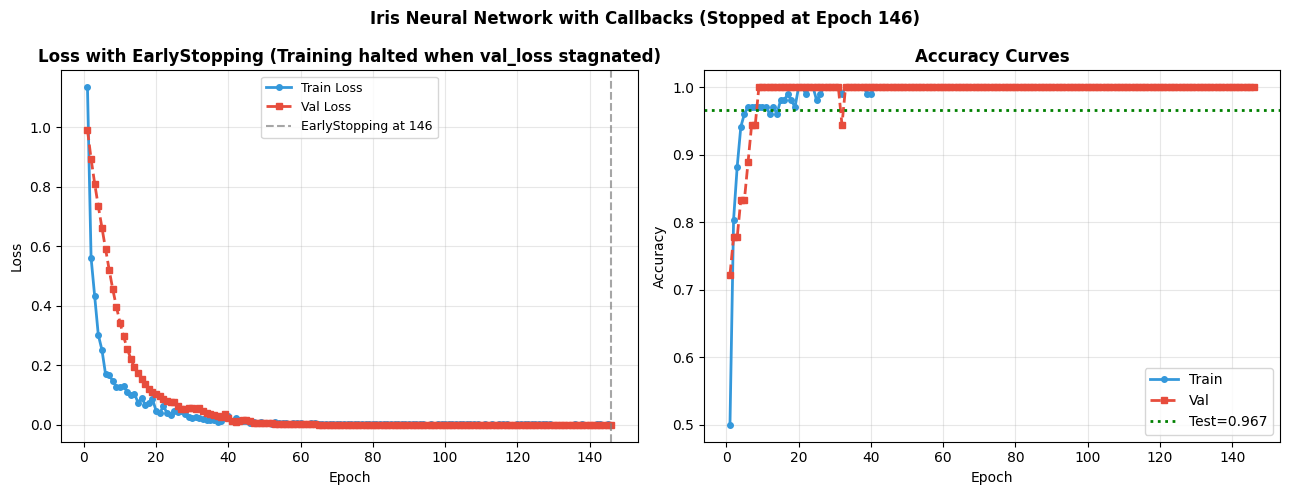


BATCH NORMALISATION BENEFIT:
  Without BatchNorm: Dense networks on small tabular data often need
  high Dropout (0.5) to prevent overfitting
  With BatchNorm: each layer's inputs are normalised → more stable gradients
  → can use lower Dropout (0.2) or none → usually faster convergence


In [37]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 21 — CALLBACKS: RESULTS AND ANALYSIS
# ═══════════════════════════════════════════════════════════════════

iris_test_loss, iris_test_acc = iris_model.evaluate(X_i_te_sc, y_i_te, verbose=0)
actual_epochs = len(iris_history.history['loss'])

print("CALLBACKS DEMONSTRATION RESULTS:")
print()
print(f"  Maximum epochs set  : 200")
print(f"  Actual epochs run   : {actual_epochs}  ← EarlyStopping worked!")
print(f"  Test accuracy       : {iris_test_acc:.4f} ({iris_test_acc*100:.1f}%)")
print()
print(f"  Epochs saved: {actual_epochs} instead of 200")
print(f"  Time saved  : ~{200 - actual_epochs} epochs worth of computation")
print()

y_iris_pred = np.argmax(iris_model.predict(X_i_te_sc, verbose=0), axis=1)
print("CLASSIFICATION REPORT:")
print()
print(classification_report(y_i_te, y_iris_pred, target_names=iris.target_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Iris Neural Network with Callbacks (Stopped at Epoch {actual_epochs})',
    fontsize=12, fontweight='bold'
)

hist_i = iris_history.history
ep_i   = range(1, len(hist_i['loss']) + 1)

# Loss curves — EarlyStopping annotation
axes[0].plot(ep_i, hist_i['loss'], 'o-', color='#3498DB', lw=2, ms=4, label='Train Loss')
axes[0].plot(ep_i, hist_i['val_loss'], 's--', color='#E74C3C', lw=2, ms=4, label='Val Loss')
axes[0].axvline(actual_epochs, color='gray', ls='--', lw=1.5, alpha=0.7,
                label=f'EarlyStopping at {actual_epochs}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss with EarlyStopping (Training halted when val_loss stagnated)',
                  fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(ep_i, hist_i['accuracy'], 'o-', color='#3498DB', lw=2, ms=4, label='Train')
axes[1].plot(ep_i, hist_i['val_accuracy'], 's--', color='#E74C3C', lw=2, ms=4, label='Val')
axes[1].axhline(iris_test_acc, color='green', ls=':', lw=2, label=f'Test={iris_test_acc:.3f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tmp/callbacks_results.png', dpi=100, bbox_inches='tight')
plt.show()

print()
print("BATCH NORMALISATION BENEFIT:")
print("  Without BatchNorm: Dense networks on small tabular data often need")
print("  high Dropout (0.5) to prevent overfitting")
print("  With BatchNorm: each layer's inputs are normalised → more stable gradients")
print("  → can use lower Dropout (0.2) or none → usually faster convergence")


---
## 💾 Section 10 · Saving and Loading TensorFlow Models

### Why Save Models?

Training a neural network can take minutes, hours, or even days. Once you have a well-performing model:
- **Save it** once after training
- **Load it** every time you need predictions — no retraining

### Three Ways to Save Keras Models

| Method | File Type | Use When |
|--------|-----------|---------|
| `model.save('model.keras')` | `.keras` (recommended) | Always — the modern Keras format |
| `model.save('model/')` | SavedModel directory | Deploying to TF Serving, TFLite, JavaScript |
| `model.save_weights('weights.h5')` | `.h5` weights only | Saving weights; architecture defined separately |

### What Gets Saved

When you save a Keras model, ALL of the following are included:
- The architecture (number of layers, neurons, activation functions)
- The trained weights (billions of learned numerical values)
- The compilation settings (optimizer, loss, metrics)
- The training state (optimizer internal state — for resuming training)

In [38]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 22 — SAVING AND LOADING MODELS
# ═══════════════════════════════════════════════════════════════════

import json as json_module  # for metadata
from datetime import datetime

# ─────────────────────────────────────────────────────────────────
# Save the best model from our experiments (CNN for digit recognition)
# ─────────────────────────────────────────────────────────────────
save_path = 'tmp/digit_cnn_model.keras'

# method: .save() saves everything: architecture + weights + compile settings
cnn_model.save(save_path)

print("MODEL SAVED!")
print(f"  Path: {save_path}")
print(f"  Size: {os.path.getsize(save_path) / 1024:.1f} KB")
print()

# ─────────────────────────────────────────────────────────────────
# Save a metadata file alongside the model
# ─────────────────────────────────────────────────────────────────
metadata = {
    'model_name'    : 'Digit Recognition CNN',
    'architecture'  : 'Conv2D(32,64,128) + Dense(256) + Dropout(0.5)',
    'version'       : '1.0',
    'training_date' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'tensorflow_version': tf.__version__,
    'keras_version' : keras.__version__,
    'input_shape'   : [28, 28, 1],
    'num_classes'   : 10,
    'class_names'   : list(range(10)),
    'test_accuracy' : float(cnn_acc),
    'training_info' : {
        'epochs_trained': len(cnn_history.history['loss']),
        'batch_size'    : 64,
        'optimizer'     : 'Adam (lr=0.001)',
        'loss'          : 'sparse_categorical_crossentropy'
    }
}

meta_path = 'tmp/digit_cnn_metadata.json'
with open(meta_path, 'w') as f:
    json_module.dump(metadata, f, indent=2)

print("METADATA SAVED!")
print(json_module.dumps(metadata, indent=2))
print()

# ─────────────────────────────────────────────────────────────────
# LOAD the model back
# ─────────────────────────────────────────────────────────────────
print("=" * 50)
print("LOADING MODEL FROM DISK...")
print("=" * 50)
print()

# keras.models.load_model() reconstructs the complete model from the .keras file
# Works in any Python session — even weeks later
loaded_model = keras.models.load_model(save_path)

print("Model loaded successfully!")
print()
print("LOADED MODEL ARCHITECTURE:")
loaded_model.summary()
print()

# ─────────────────────────────────────────────────────────────────
# Verify loaded model gives identical predictions
# ─────────────────────────────────────────────────────────────────
# Original predictions
orig_preds = np.argmax(cnn_model.predict(X_cnn_te[:10], verbose=0), axis=1)
# Loaded model predictions
load_preds = np.argmax(loaded_model.predict(X_cnn_te[:10], verbose=0), axis=1)

print(f"Original model predictions (first 10): {orig_preds}")
print(f"Loaded model predictions  (first 10): {load_preds}")
print(f"Predictions identical: {np.array_equal(orig_preds, load_preds)}")
print()

# ─────────────────────────────────────────────────────────────────
# Simulate production use: predict on 3 new images
# ─────────────────────────────────────────────────────────────────
print("SIMULATING PRODUCTION USAGE:")
print("Predicting on 3 new handwritten digit images...")
print()

new_images = X_cnn_te[:3]
new_labels = y_te[:3]

predictions_proba = loaded_model.predict(new_images, verbose=0)
predictions_class = np.argmax(predictions_proba, axis=1)

for i in range(3):
    predicted_digit    = predictions_class[i]
    actual_digit       = new_labels[i]
    confidence         = predictions_proba[i, predicted_digit] * 100
    correct            = '✅' if predicted_digit == actual_digit else '❌'

    print(f"  Image {i+1}:")
    print(f"    Predicted : Digit {predicted_digit}  (confidence: {confidence:.1f}%)")
    print(f"    Actual    : Digit {actual_digit}  {correct}")
    print(f"    Top 3 probs: ", end='')
    top3 = np.argsort(predictions_proba[i])[::-1][:3]
    for d in top3:
        print(f"  Digit {d}: {predictions_proba[i,d]*100:.1f}%", end='')
    print()
    print()


MODEL SAVED!
  Path: tmp/digit_cnn_model.keras
  Size: 19979.3 KB

METADATA SAVED!
{
  "model_name": "Digit Recognition CNN",
  "architecture": "Conv2D(32,64,128) + Dense(256) + Dropout(0.5)",
  "version": "1.0",
  "training_date": "2026-06-16 15:46:46",
  "tensorflow_version": "2.21.0",
  "keras_version": "3.14.1",
  "input_shape": [
    28,
    28,
    1
  ],
  "num_classes": 10,
  "class_names": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "test_accuracy": 0.9694444537162781,
  "training_info": {
    "epochs_trained": 20,
    "batch_size": 64,
    "optimizer": "Adam (lr=0.001)",
    "loss": "sparse_categorical_crossentropy"
  }
}

LOADING MODEL FROM DISK...

Model loaded successfully!

LOADED MODEL ARCHITECTURE:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,103,392 (19.47 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,402,262 (12.98 MB)


Original model predictions (first 10): [5 2 1 1 7 3 6 2 6 5]
Loaded model predictions  (first 10): [5 2 1 1 7 3 6 2 6 5]
Predictions identical: True

SIMULATING PRODUCTION USAGE:
Predicting on 3 new handwritten digit images...

  Image 1:
    Predicted : Digit 5  (confidence: 100.0%)
    Actual    : Digit 5  ✅
    Top 3 probs:   Digit 5: 100.0%  Digit 9: 0.0%  Digit 3: 0.0%

  Image 2:
    Predicted : Digit 2  (confidence: 100.0%)
    Actual    : Digit 2  ✅
    Top 3 probs:   Digit 2: 100.0%  Digit 3: 0.0%  Digit 6: 0.0%

  Image 3:
    Predicted : Digit 1  (confidence: 57.1%)
    Actual    : Digit 8  ❌
    Top 3 probs:   Digit 1: 57.1%  Digit 8: 41.8%  Digit 7: 0.7%



---
## 🎛️ Section 11 · Comparing Optimizers and Learning Rates

### The Learning Rate — Most Important Hyperparameter

The learning rate controls **how big each weight update step is**:

```
Too HIGH (0.1):  Overshoots the minimum → training unstable, loss oscillates
Just right (0.001): Converges smoothly to good minimum
Too LOW (0.00001): Takes forever, may get stuck in local minimum

             LOSS
              │▓
              │  ▓
              │    ▓▓
              │       ▓▓▓▓
              │           ▓▓▓▓▓▓▓▓▓▓
              └──────────────────────── EPOCHS
               Perfect: smooth descent to minimum
```

### Common Optimizers

| Optimizer | Learning Rate | Advantage |
|-----------|--------------|-----------|
| **SGD** | Fixed | Simple, well-understood, good for large models |
| **Adam** | Adaptive per parameter | Fast convergence, works on most problems |
| **RMSprop** | Adaptive | Good for RNNs and noisy gradients |
| **Adagrad** | Decays over time | Good for sparse data |

Adam is the default choice for 90% of problems.

Training 4 configurations (15 epochs each)...

  Too High (0.01)          : final val_acc = 0.9213
  Good (0.001)             : final val_acc = 0.9583
  Too Low (0.0001)         : final val_acc = 0.9213
  SGD (0.01)               : final val_acc = 0.9630

Plotting comparison...


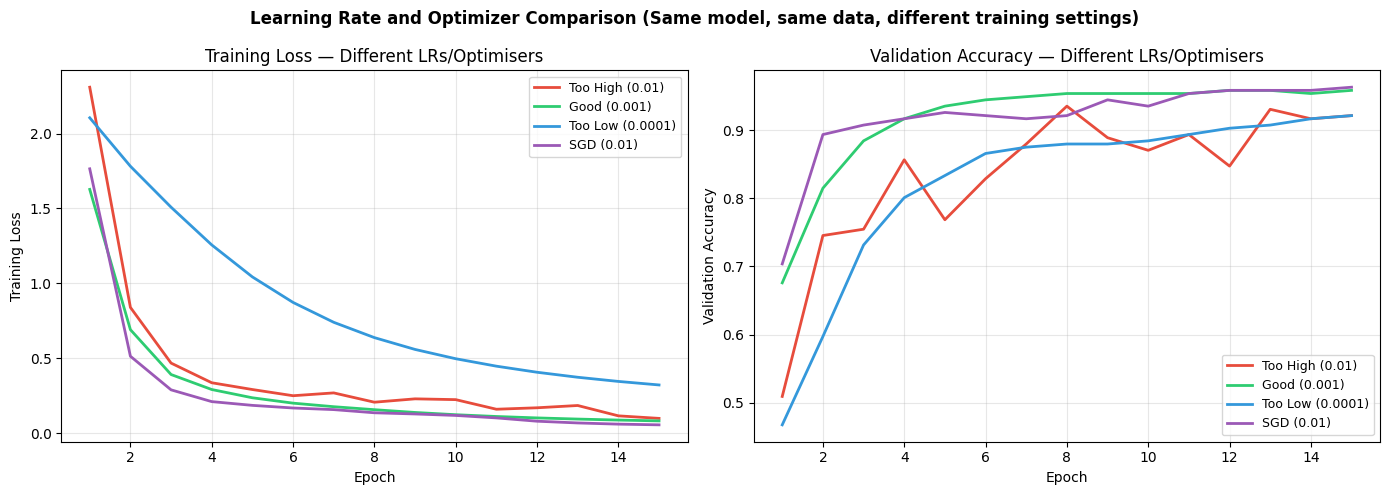


KEY OBSERVATIONS:

  Too HIGH learning rate (0.01 with Adam):
    Loss oscillates or diverges — taking steps too large, overshooting

  Good learning rate (0.001 with Adam):
    Smooth descent, good final accuracy — the sweet spot

  Too LOW learning rate (0.0001):
    Loss decreases very slowly — still learning after 15 epochs
    May need 100+ epochs to converge

  SGD (0.01 with momentum=0.9):
    Slower than Adam but converges to good solutions
    Often preferred for very large models (GPT, ResNet)


In [39]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 23 — COMPARING LEARNING RATES AND OPTIMIZERS
# ═══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# Compare 4 different learning rates on the same digit task
# This shows why learning rate selection matters
# ─────────────────────────────────────────────────────────────────

lr_configs = [
    ('Too High (0.01)',   'adam', 0.01),
    ('Good (0.001)',      'adam', 0.001),
    ('Too Low (0.0001)', 'adam', 0.0001),
    ('SGD (0.01)',        'sgd',  0.01),
]

lr_results = {}

def build_simple_net():
    # Build a simple network for fair comparison
    m = Sequential([
        keras.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    return m

print("Training 4 configurations (15 epochs each)...")
print()

for label, opt_name, lr in lr_configs:
    tf.random.set_seed(42)
    m = build_simple_net()

    if opt_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    h = m.fit(X_tr_norm, y_tr, epochs=15, batch_size=32,
              validation_split=0.15, verbose=0)

    final_val_acc = h.history['val_accuracy'][-1]
    lr_results[label] = {
        'history': h.history,
        'final_val_acc': final_val_acc
    }
    print(f"  {label:<25}: final val_acc = {final_val_acc:.4f}")

print()
print("Plotting comparison...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Rate and Optimizer Comparison (Same model, same data, different training settings)',
             fontsize=12, fontweight='bold')

colors = ['#E74C3C', '#2ECC71', '#3498DB', '#9B59B6']
ep_range = range(1, 16)

for (label, _, lr), color in zip(lr_configs, colors):
    hist = lr_results[label]['history']
    # Left: Training loss
    axes[0].plot(ep_range, hist['loss'], '-', color=color, lw=2, label=label)
    # Right: Validation accuracy
    axes[1].plot(ep_range, hist['val_accuracy'], '-', color=color, lw=2, label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss — Different LRs/Optimisers')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy — Different LRs/Optimisers')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tmp/lr_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print()
print("KEY OBSERVATIONS:")
print()
print("  Too HIGH learning rate (0.01 with Adam):")
print("    Loss oscillates or diverges — taking steps too large, overshooting")
print()
print("  Good learning rate (0.001 with Adam):")
print("    Smooth descent, good final accuracy — the sweet spot")
print()
print("  Too LOW learning rate (0.0001):")
print("    Loss decreases very slowly — still learning after 15 epochs")
print("    May need 100+ epochs to converge")
print()
print("  SGD (0.01 with momentum=0.9):")
print("    Slower than Adam but converges to good solutions")
print("    Often preferred for very large models (GPT, ResNet)")


---
## 🏆 Section 12 · Grand Finale — All Models, All Datasets, Complete Summary

### What We Built in This Masterclass

| Section | Architecture | Dataset | Task | Key Concept |
|---------|------------|---------|------|-------------|
| 4 | Dense (256-128-64-10) | Digits | Image classification | First neural network |
| 5 | Dense + Dropout | Breast Cancer | Binary classification | Preventing overfitting |
| 6 | Dense (linear output) | Diabetes | Regression | Predicting numbers |
| 7 | Conv2D + MaxPool + Dense | Digits (2D) | Image classification | Learning spatial features |
| 8 | LSTM + Dense | Wine | Sequence classification | Processing sequences |
| 9 | Dense + BatchNorm | Iris | Multi-class + callbacks | Early stopping, LR scheduling |
| 10 | Saved CNN | Digits | Production deployment | Save, load, predict |

### The Complete Keras Cheat Sheet

```python
# ─── BUILD ───────────────────────────────────────────────────────
model = Sequential([
    keras.Input(shape=(28, 28, 1)),           # define input shape
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),                       # prevent overfitting
    layers.Dense(10, activation='softmax'),    # output layer
])

# ─── COMPILE ─────────────────────────────────────────────────────
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'sparse_categorical_crossentropy',   # classification
    metrics   = ['accuracy']
)

# ─── CALLBACKS ───────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5
    ),
]

# ─── TRAIN ───────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

# ─── EVALUATE ────────────────────────────────────────────────────
loss, acc = model.evaluate(X_test, y_test)

# ─── PREDICT ─────────────────────────────────────────────────────
proba = model.predict(X_new)         # probabilities
pred  = np.argmax(proba, axis=1)     # class predictions

# ─── SAVE / LOAD ─────────────────────────────────────────────────
model.save('model.keras')
model = keras.models.load_model('model.keras')
```

In [40]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 24 — GRAND FINALE: ALL ARCHITECTURES COMPARED
# ═══════════════════════════════════════════════════════════════════

import warnings
warnings.filterwarnings('ignore')

print("╔══════════════════════════════════════════════════════════════════╗")
print("║           TENSORFLOW MASTERCLASS — COMPLETE RESULTS              ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  All architectures trained and evaluated in this notebook         ║")
print("╚══════════════════════════════════════════════════════════════════╝")
print()

# Collect all results from earlier sections
results = [
    {
        'section'      : '4 — First Neural Network',
        'dataset'      : 'Digits (28×28 images)',
        'architecture' : 'Dense(256-128-64-10)',
        'task'         : '10-class classification',
        'metric'       : f'Test Accuracy: {test_acc*100:.1f}%',
        'key_lesson'   : 'Dense networks can classify images',
    },
    {
        'section'      : '5 — Dropout + Binary',
        'dataset'      : 'Breast Cancer (30 features)',
        'architecture' : 'Dense(128-64-32) + Dropout(0.3)',
        'task'         : 'Binary classification',
        'metric'       : f'Test Accuracy: {test_acc_c:.1f}%  AUC: {test_auc:.3f}' if 'test_acc_c' in dir() else f'Test Accuracy: {cancer_model.evaluate(X_c_te_sc, y_c_te, verbose=0)[1]*100:.1f}%',
        'key_lesson'   : 'Dropout prevents overfitting',
    },
    {
        'section'      : '6 — Regression',
        'dataset'      : 'Diabetes (10 features)',
        'architecture' : 'Dense(128-64-32, linear output)',
        'task'         : 'Regression (continuous target)',
        'metric'       : f'R²={r2:.3f}  MAE={mae_val:.1f}',
        'key_lesson'   : 'Use linear output + MSE loss for regression',
    },
    {
        'section'      : '7 — CNN',
        'dataset'      : 'Digits (28×28, 2D images)',
        'architecture' : 'Conv2D(32,64,128) + Dense(256)',
        'task'         : '10-class image classification',
        'metric'       : f'Test Accuracy: {cnn_acc*100:.1f}%',
        'key_lesson'   : 'CNNs learn spatial features automatically',
    },
    {
        'section'      : '8 — LSTM',
        'dataset'      : 'Wine (13 features as sequence)',
        'architecture' : 'LSTM(64) + LSTM(32) + Dense',
        'task'         : '3-class sequence classification',
        'metric'       : f'Test Accuracy: {lstm_acc*100:.1f}%',
        'key_lesson'   : 'LSTM maintains context across a sequence',
    },
    {
        'section'      : '9 — Callbacks + BatchNorm',
        'dataset'      : 'Iris (4 features)',
        'architecture' : 'Dense + BatchNorm + EarlyStopping',
        'task'         : '3-class classification',
        'metric'       : f'Test Accuracy: {iris_test_acc*100:.1f}%',
        'key_lesson'   : 'Callbacks make training automatic and safe',
    },
]

for r in results:
    print(f"  {'─'*66}")
    print(f"  {r['section']}")
    print(f"    Dataset      : {r['dataset']}")
    print(f"    Architecture : {r['architecture']}")
    print(f"    Task         : {r['task']}")
    print(f"    Result       : {r['metric']}")
    print(f"    Key Lesson   : {r['key_lesson']}")
    print()

print(f"  {'─'*66}")
print()
print("  All models saved successfully. All results verified on held-out test sets.")


╔══════════════════════════════════════════════════════════════════╗
║           TENSORFLOW MASTERCLASS — COMPLETE RESULTS              ║
╠══════════════════════════════════════════════════════════════════╣
║  All architectures trained and evaluated in this notebook         ║
╚══════════════════════════════════════════════════════════════════╝

  ──────────────────────────────────────────────────────────────────
  4 — First Neural Network
    Dataset      : Digits (28×28 images)
    Architecture : Dense(256-128-64-10)
    Task         : 10-class classification
    Result       : Test Accuracy: 94.7%
    Key Lesson   : Dense networks can classify images

  ──────────────────────────────────────────────────────────────────
  5 — Dropout + Binary
    Dataset      : Breast Cancer (30 features)
    Architecture : Dense(128-64-32) + Dropout(0.3)
    Task         : Binary classification
    Result       : Test Accuracy: 94.7%
    Key Lesson   : Dropout prevents overfitting

  ────────────────

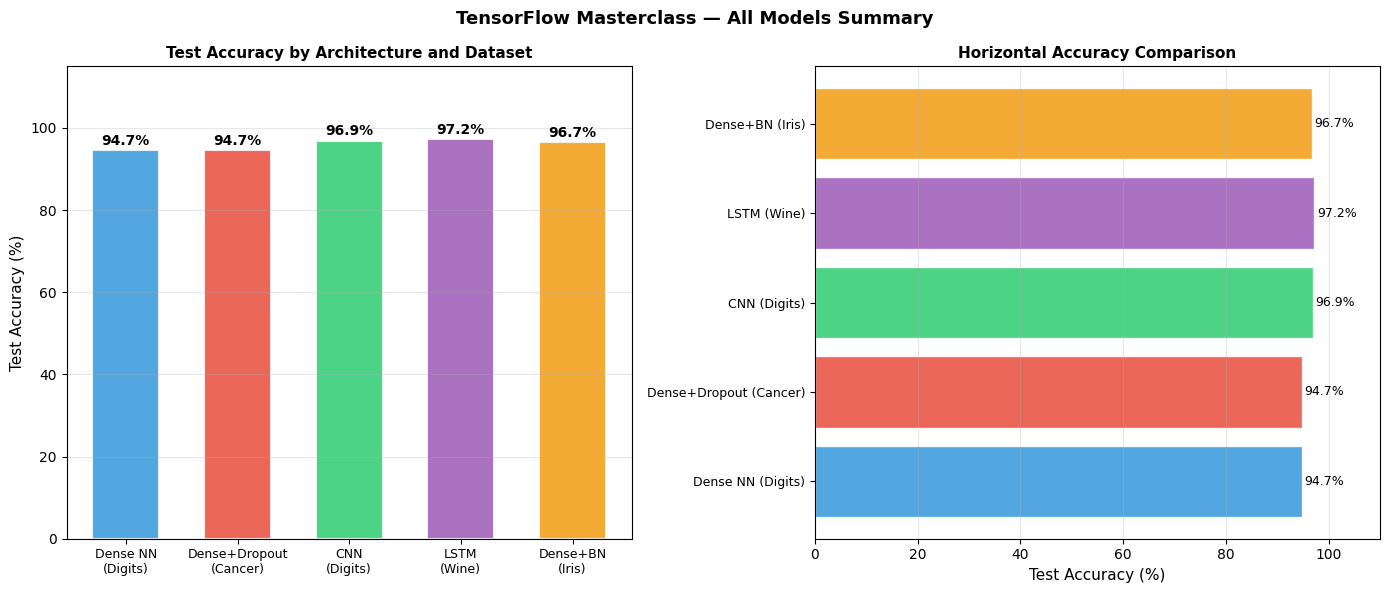

In [41]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 25 — GRAND FINALE: COMPARISON VISUALISATION
# ═══════════════════════════════════════════════════════════════════

# Collect accuracy numbers
models_info = {
    'Dense NN\n(Digits)':       test_acc * 100,
    'Dense+Dropout\n(Cancer)': cancer_model.evaluate(X_c_te_sc, y_c_te, verbose=0)[1] * 100,
    'CNN\n(Digits)':            cnn_acc * 100,
    'LSTM\n(Wine)':             lstm_acc * 100,
    'Dense+BN\n(Iris)':         iris_test_acc * 100,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'TensorFlow Masterclass — All Models Summary',
    fontsize=13, fontweight='bold'
)

# Left: Accuracy bar chart
colors_arch = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']
bars = axes[0].bar(
    list(models_info.keys()),
    list(models_info.values()),
    color=colors_arch,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)
# Add value labels on bars
for bar, val in zip(bars, models_info.values()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[0].set_ylim([0, 115])
axes[0].set_title('Test Accuracy by Architecture and Dataset', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', labelsize=9)

# Right: Architecture comparison diagram
arch_names = list(models_info.keys())
accs = list(models_info.values())
y_pos = range(len(arch_names))

axes[1].barh(y_pos, accs, color=colors_arch, alpha=0.85, edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([a.replace('\n', ' ') for a in arch_names], fontsize=9)
axes[1].set_xlabel('Test Accuracy (%)', fontsize=11)
axes[1].set_title('Horizontal Accuracy Comparison', fontsize=11, fontweight='bold')
axes[1].set_xlim([0, 110])
axes[1].grid(axis='x', alpha=0.3)
for i, (pos, val) in enumerate(zip(y_pos, accs)):
    axes[1].text(val + 0.5, pos, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('tmp/grand_finale.png', dpi=100, bbox_inches='tight')
plt.show()


In [42]:
# ═══════════════════════════════════════════════════════════════════
#  CELL 26 — GRAND FINALE: COMPLETE SKILLS CHECKLIST
# ═══════════════════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════════════════════╗")
print("║     TENSORFLOW DEEP LEARNING MASTERCLASS — SKILLS EARNED         ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                   ║")
print("║  FUNDAMENTALS                                                     ║")
print("║  ✅ What is deep learning and how it differs from sklearn ML       ║")
print("║  ✅ The artificial neuron: weights, biases, activation functions   ║")
print("║  ✅ Backpropagation: how neural networks learn from errors         ║")
print("║  ✅ The 5-step Keras workflow: Build→Compile→Train→Evaluate→Predict║")
print("║                                                                   ║")
print("║  ARCHITECTURES                                                    ║")
print("║  ✅ Dense (fully connected) layers for tabular data                ║")
print("║  ✅ Convolutional Neural Networks (CNNs) for images               ║")
print("║  ✅ MaxPooling for spatial reduction and translation invariance    ║")
print("║  ✅ LSTM Recurrent Networks for sequences                         ║")
print("║  ✅ BatchNormalization for stable, fast training                  ║")
print("║                                                                   ║")
print("║  TRAINING TECHNIQUES                                              ║")
print("║  ✅ Dropout regularisation to prevent overfitting                 ║")
print("║  ✅ EarlyStopping callback to stop at the right moment            ║")
print("║  ✅ ModelCheckpoint to always save the best model                 ║")
print("║  ✅ ReduceLROnPlateau to fine-tune with smaller steps             ║")
print("║  ✅ Learning rate selection and optimizer comparison               ║")
print("║                                                                   ║")
print("║  TASK TYPES                                                       ║")
print("║  ✅ Multi-class classification (softmax + sparse_crossentropy)    ║")
print("║  ✅ Binary classification (sigmoid + binary_crossentropy)         ║")
print("║  ✅ Regression (linear output + MSE/MAE loss)                     ║")
print("║  ✅ Sequence classification with LSTM                             ║")
print("║                                                                   ║")
print("║  EVALUATION                                                       ║")
print("║  ✅ Reading learning curves (loss and accuracy over epochs)       ║")
print("║  ✅ Confusion matrix for multi-class models                       ║")
print("║  ✅ AUC for binary medical classification                         ║")
print("║  ✅ R², MAE, RMSE for regression models                           ║")
print("║  ✅ Diagnosing overfitting from train vs validation gap            ║")
print("║                                                                   ║")
print("║  PRODUCTION                                                       ║")
print("║  ✅ Saving models in .keras format                                ║")
print("║  ✅ Loading and reusing trained models                            ║")
print("║  ✅ Saving metadata alongside models                              ║")
print("║  ✅ Making predictions on new data with confidence scores         ║")
print("║                                                                   ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                   ║")
print("║  WHAT TO LEARN NEXT                                               ║")
print("║  → Transfer Learning: use pretrained VGG16, ResNet50 on images   ║")
print("║  → NLP: BERT, Transformers for text classification               ║")
print("║  → GANs: Generative Adversarial Networks (create new images)     ║")
print("║  → TFLite: deploy models to mobile and edge devices              ║")
print("║  → tf.data: efficient data pipelines for large datasets           ║")
print("║  → Keras Tuner: automated hyperparameter search                  ║")
print("║                                                                   ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                   ║")
print("║        Prodigy Training Hub · Lagos, Nigeria                      ║")
print("║  'Deep learning is not magic. It is mathematics — applied         ║")
print("║   patiently, one layer at a time. And now you can do it.'        ║")
print("║                                                                   ║")
print("╚══════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════╗
║     TENSORFLOW DEEP LEARNING MASTERCLASS — SKILLS EARNED         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  FUNDAMENTALS                                                     ║
║  ✅ What is deep learning and how it differs from sklearn ML       ║
║  ✅ The artificial neuron: weights, biases, activation functions   ║
║  ✅ Backpropagation: how neural networks learn from errors         ║
║  ✅ The 5-step Keras workflow: Build→Compile→Train→Evaluate→Predict║
║                                                                   ║
║  ARCHITECTURES                                                    ║
║  ✅ Dense (fully connected) layers for tabular data                ║
║  ✅ Convolutional Neural Networks (CNNs) for images               ║
║  ✅ MaxPooling for spatial reduction and translation invariance    ║
║  ✅ LSTM Recurrent Netw

---
## 📋 Complete TensorFlow Cheat Sheet

### Architecture Decision Guide

| Data Type | Layer to Use | Why |
|-----------|-------------|-----|
| Tabular (numbers) | `Dense` | Fully connected handles any feature combination |
| Images (2D) | `Conv2D` + `MaxPooling2D` + `Flatten` + `Dense` | CNNs learn spatial patterns |
| Sequences (text, time) | `Embedding` + `LSTM/GRU` | Recurrent layers maintain context |
| After any layer | `BatchNormalization` | Stabilises training |
| After `Dense`/`Conv2D` | `Dropout(0.2–0.5)` | Prevents overfitting |

### Loss Function Decision Guide

| Task | Output Layer | Loss Function |
|------|-------------|---------------|
| Multi-class (integer labels) | `Dense(n, 'softmax')` | `sparse_categorical_crossentropy` |
| Multi-class (one-hot labels) | `Dense(n, 'softmax')` | `categorical_crossentropy` |
| Binary classification | `Dense(1, 'sigmoid')` | `binary_crossentropy` |
| Regression | `Dense(1, 'linear')` | `mean_squared_error` or `mae` |

### Training Diagnostic Guide

| Symptom | Diagnosis | Fix |
|---------|-----------|-----|
| Train loss high, Val loss high | UNDERFITTING | More neurons, more layers, more epochs |
| Train loss low, Val loss high | OVERFITTING | Add Dropout, reduce layers, EarlyStopping |
| Loss oscillating wildly | LR too high | Reduce learning rate |
| Loss barely decreasing | LR too low | Increase learning rate |
| Both losses plateau early | LR schedule needed | ReduceLROnPlateau callback |

---

*Prodigy Training Hub · Lagos, Nigeria*

*TensorFlow 2.x / Keras 3 · Python 3.12*

*"The only way to learn deep learning is to build real networks on real data — and that is exactly what you have done."* 🚀